<a href="https://colab.research.google.com/github/anyuanay/INFO213/blob/main/FARR_STEM_Module3_data_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FARR-STEM Program
## Module 3: Data Visualization
### Yuan An, PhD
### College of Computing and Informatics
### Drexel University

This notebook translates the full instructional module into executable Python code.
Each unit combines explanatory markdown, working code, and exercises you can run and modify.

<div style="font-size:18px">

| Unit | Topic |
|------|-------|
| 1 | Descriptive Statistics Foundations |
| 2 | Visualization Patterns & Chart Types |
| 3 | Conveying Insights Effectively |
| 4 | Communicating with Stakeholders |
| 5 | Hands-On Workshop |

</div>


## Setup: Run This First

Install and import all dependencies used throughout the module.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scipy as sp

from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Notebook-wide style
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# Shared color palette
PALETTE = {
    'blue':    '#2563EB',
    'green':   '#059669',
    'amber':   '#D97706',
    'red':     '#DC2626',
    'violet':  '#7C3AED',
    'cyan':    '#0891B2',
    'orange':  '#F97316',
    'gray':    '#6B7280',
}
CAT_COLORS = [PALETTE['blue'], PALETTE['green'], PALETTE['amber'],
              PALETTE['red'], PALETTE['violet'], PALETTE['cyan']]

REGION_COLORS = {
    'Europe': '#2563EB', 'Americas': '#059669',
    'Asia': '#D97706', 'Africa': '#DC2626', 'Oceania': '#7C3AED'
}

## Datasets

All datasets used throughout the module are defined here. Run this cell before any unit.

In [ ]:
# Dataset 1: Exam Scores (n=30)
exam_scores = np.array([
    72, 85, 91, 68, 77, 83, 79, 92, 65, 88,
    76, 84, 71, 89, 80, 74, 87, 95, 66, 82,
    78, 90, 73, 86, 81, 69, 93, 75, 88, 70
])

# Dataset 2: Apartment Rental Prices ($)
rental_prices = np.array([
     850,  920, 1100, 1850, 1200,  975, 1050, 1400, 1650,  890,
    1300, 1750, 2100,  980, 1125, 1450, 1600,  925, 1075, 3200,
    1350, 1250, 1550, 2400,  895, 1175, 1425, 1700,  950, 1000
])

# Dataset 3: Adult Heights (cm)
heights = np.array([
    162, 158, 170, 175, 164, 168, 172, 160, 176, 163,
    169, 171, 165, 174, 167, 173, 161, 178, 166, 179,
    159, 177, 164, 170, 168, 172, 161, 175, 166, 180,
    163, 169, 157, 174, 171, 165, 176, 168, 162, 172
])

# Dataset 4: World Health (Gapminder-style)
world_health = pd.DataFrame([
    ('Norway',      'Europe',   67200, 83.2,  5.4),
    ('USA',         'Americas', 65000, 78.5,  331),
    ('Australia',   'Oceania',  52800, 83.4,   25),
    ('Sweden',      'Europe',   51600, 82.7,   10),
    ('Germany',     'Europe',   45700, 81.0,   83),
    ('Canada',      'Americas', 43300, 82.3,   38),
    ('France',      'Europe',   40500, 82.5,   68),
    ('UK',          'Europe',   40300, 81.3,   67),
    ('Japan',       'Asia',     40000, 84.3,  126),
    ('S. Korea',    'Asia',     31500, 83.5,   52),
    ('Mexico',      'Americas',  9900, 75.1,  129),
    ('Argentina',   'Americas',  9900, 76.7,   45),
    ('China',       'Asia',     10500, 77.3, 1440),
    ('Brazil',      'Americas',  8900, 75.7,  215),
    ('Egypt',       'Africa',    3600, 72.0,  102),
    ('S. Africa',   'Africa',    6000, 64.1,   60),
    ('Indonesia',   'Asia',      4200, 71.7,  274),
    ('India',       'Asia',      2100, 69.7, 1380),
    ('Nigeria',     'Africa',    2100, 62.3,  206),
    ('Ethiopia',    'Africa',     840, 66.5,  115),
], columns=['country', 'region', 'gdp_per_capita', 'life_expectancy', 'population_M'])

# Dataset 5: Monthly Retail Sales ($K)
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_sales = pd.DataFrame({
    'month':       months,
    'electronics': [42, 38, 45, 51, 48, 55, 60, 58, 52, 64,  89,  95],
    'clothing':    [35, 32, 48, 52, 58, 45, 43, 49, 55, 62,  78,  85],
    'furniture':   [28, 31, 44, 53, 60, 55, 52, 54, 49, 47,  58,  62],
    'food':        [88, 82, 91, 87, 93, 95, 98, 96, 92, 94, 108, 125],
})

# Dataset 6: Temperature Anomalies
temp_data = pd.DataFrame({
    'year':  [1960,1965,1970,1975,1980,1985,1990,1995,2000,2005,2010,2015,2020,2023],
    'anomaly':[-0.02,0.04,0.03,0.01,0.27,0.13,0.44,0.38,0.42,0.68,0.72,0.90,1.02,1.46]
})

print("All datasets loaded.")
print(f"   exam_scores      : n={len(exam_scores)}")
print(f"   rental_prices    : n={len(rental_prices)}")
print(f"   heights          : n={len(heights)}")
print(f"   world_health     : {world_health.shape}")
print(f"   monthly_sales    : {monthly_sales.shape}")
print(f"   temp_data        : {temp_data.shape}")


All datasets loaded.
   exam_scores      : n=30
   rental_prices    : n=30
   heights          : n=40
   world_health     : (20, 5)
   monthly_sales    : (12, 5)
   temp_data        : (14, 2)


---
# Unit 1 Descriptive Statistics Foundations

Before we visualize data, we need to understand it numerically.
Descriptive statistics give us a precise vocabulary for **shape**, **center**, and **spread**,
the raw ingredients of any good chart.

### Learning objectives
- Calculate mean, median, mode and know when each is misleading
- Quantify spread using range, standard deviation, and IQR
- Identify skewness and outliers before picking a chart type


## 1.1 Measures of Central Tendency

Three measures describe the "center" of a dataset:

| Measure | Formula | Best for | Weakness |
|---------|---------|----------|----------|
| **Mean** | $\frac{\Sigma x_i}{n}$ | Symmetric distributions | Pulled by outliers |
| **Median** | Middle value (50th pct) | Skewed data, prices, incomes | Ignores magnitude of extremes |
| **Mode** | Most frequent value | Categorical data | May not exist or be non-unique |

> **Key insight:** When mean $\neq$ median, your data is skewed. The gap between them reveals *how much* an outlier problem you have.


In [ ]:
def describe_central_tendency(data, name="Dataset"):
    """Print a full central tendency report for a numeric array."""
    arr = np.array(data)
    mn  = np.mean(arr)
    med = np.median(arr)
    mode_res = sp.stats.mode(arr, keepdims=True)
    mo  = mode_res.mode[0]
    print(f"{'─'*45}")
    print(f"  Central Tendency Report — {name}")
    print(f"{'─'*45}")
    print(f"  Mean          : {mn:.2f}")
    print(f"  Median        : {med:.2f}")
    print(f"  Mode          : {mo}")
    print(f"  Mean − Median : {mn - med:+.2f}  {'(right skew)' if mn>med else '(left skew)' if mn<med else '(symmetric)'}")
    print(f"{'─'*45}")

describe_central_tendency(exam_scores,   "Exam Scores")
describe_central_tendency(rental_prices, "Rental Prices ($)")
describe_central_tendency(heights,       "Heights (cm)")


─────────────────────────────────────────────
  Central Tendency Report — Exam Scores
─────────────────────────────────────────────
  Mean          : 80.23
  Median        : 80.50
  Mode          : 88
  Mean − Median : -0.27  (left skew)
─────────────────────────────────────────────
─────────────────────────────────────────────
  Central Tendency Report — Rental Prices ($)
─────────────────────────────────────────────
  Mean          : 1369.50
  Median        : 1225.00
  Mode          : 850
  Mean − Median : +144.50  (right skew)
─────────────────────────────────────────────
─────────────────────────────────────────────
  Central Tendency Report — Heights (cm)
─────────────────────────────────────────────
  Mean          : 168.50
  Median        : 168.50
  Mode          : 168
  Mean − Median : +0.00  (symmetric)
─────────────────────────────────────────────


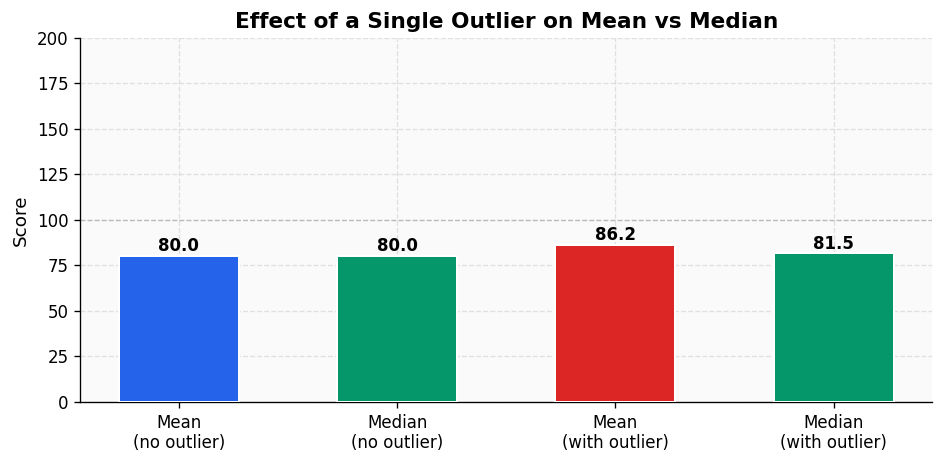


Notice: one outlier (score=180) shifts the mean by 6.2 points but the median by only 1.5 points.


In [ ]:
# Visualising the effect of a single outlier on mean vs median
base  = exam_scores[:15]
with_outlier = np.append(base, 180)   # one extreme value added

labels = ['Mean\n(no outlier)', 'Median\n(no outlier)',
          'Mean\n(with outlier)', 'Median\n(with outlier)']
values = [np.mean(base), np.median(base),
          np.mean(with_outlier), np.median(with_outlier)]
colors = [PALETTE['blue'], PALETTE['green'], PALETTE['red'], PALETTE['green']]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=1.2,
              width=0.55, zorder=3)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, 200)
ax.set_ylabel("Score")
ax.set_title("Effect of a Single Outlier on Mean vs Median")
ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.4)
plt.tight_layout()
plt.show()

print("\nNotice: one outlier (score=180) shifts the mean by",
      f"{np.mean(with_outlier)-np.mean(base):.1f} points but the median by only",
      f"{np.median(with_outlier)-np.median(base):.1f} points.")


## 1.2 Variability & Spread

Two datasets with the **same mean** can look completely different.
Spread tells us how *consistent* or *dispersed* values are.

| Measure | Formula                            | Interpretation |
|---------|------------------------------------|----------------|
| **Range** | max − min | Simple but fragile (one outlier inflates it) |
| **IQR** | Q3 − Q1 | Middle 50% of data; robust to outliers |
| **Variance** | $\frac{\Sigma(x_i-\bar{x})^2}{n}$ | Squared units - hard to interpret directly |
| **Std Dev (σ)** | $\sqrt{Variance}$ | Same units as data - most useful |
| **CV** | $\frac{\sigma}{mean}\times 100\%$  | Compares spread across different scales |


In [ ]:
def describe_spread(data, name="Dataset", currency=False):
    """Print a full variability report."""
    arr = np.array(data)
    q1, q3 = np.percentile(arr, [25, 75])
    iqr = q3 - q1
    sd  = np.std(arr, ddof=1)   # sample std dev
    cv  = (sd / np.mean(arr)) * 100
    fmt = lambda v: f"${v:,.0f}" if currency else f"{v:.2f}"
    print(f"{'─'*45}")
    print(f"  Spread Report — {name}")
    print(f"{'─'*45}")
    print(f"  Min           : {fmt(arr.min())}")
    print(f"  Q1 (25th pct) : {fmt(q1)}")
    print(f"  Median        : {fmt(np.median(arr))}")
    print(f"  Q3 (75th pct) : {fmt(q3)}")
    print(f"  Max           : {fmt(arr.max())}")
    print(f"  Range         : {fmt(arr.max() - arr.min())}")
    print(f"  IQR           : {fmt(iqr)}")
    print(f"  Std Dev       : {fmt(sd)}")
    print(f"  CV            : {cv:.1f}%")
    print(f"{'─'*45}\n")

describe_spread(exam_scores,   "Exam Scores")
describe_spread(rental_prices, "Rental Prices", currency=True)
describe_spread(heights,       "Heights (cm)")


─────────────────────────────────────────────
  Spread Report — Exam Scores
─────────────────────────────────────────────
  Min           : 65.00
  Q1 (25th pct) : 73.25
  Median        : 80.50
  Q3 (75th pct) : 87.75
  Max           : 95.00
  Range         : 30.00
  IQR           : 14.50
  Std Dev       : 8.66
  CV            : 10.8%
─────────────────────────────────────────────

─────────────────────────────────────────────
  Spread Report — Rental Prices
─────────────────────────────────────────────
  Min           : $850
  Q1 (25th pct) : $985
  Median        : $1,225
  Q3 (75th pct) : $1,588
  Max           : $3,200
  Range         : $2,350
  IQR           : $602
  Std Dev       : $517
  CV            : 37.8%
─────────────────────────────────────────────

─────────────────────────────────────────────
  Spread Report — Heights (cm)
─────────────────────────────────────────────
  Min           : 157.00
  Q1 (25th pct) : 163.75
  Median        : 168.50
  Q3 (75th pct) : 173.25
  Max 

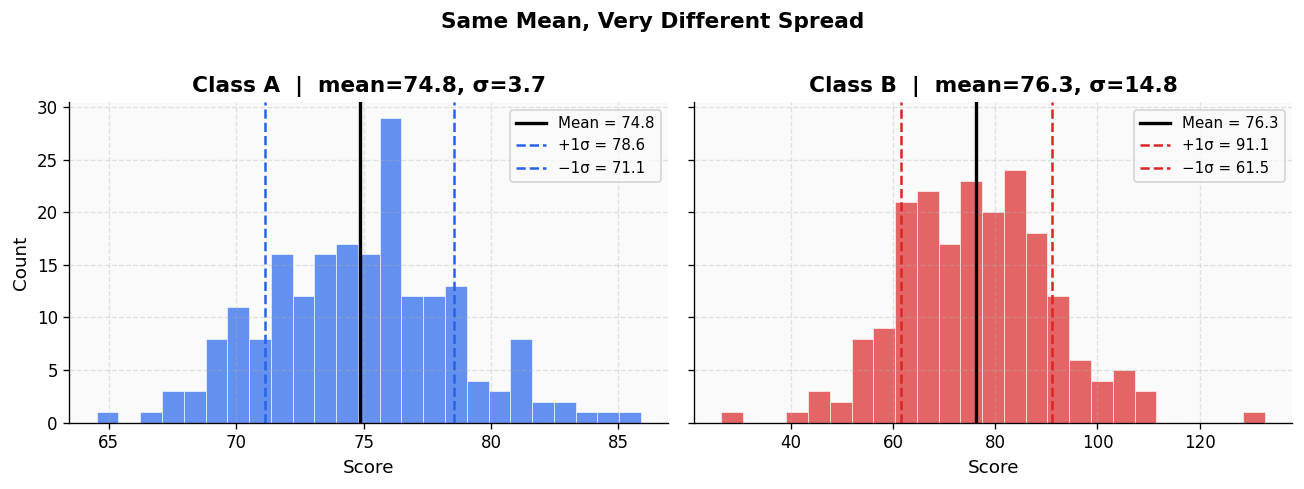

In [ ]:
# Two classes: same mean, very different spread
np.random.seed(42)
class_a = np.random.normal(loc=75, scale=4,  size=200)   # tight distribution
class_b = np.random.normal(loc=75, scale=15, size=200)   # wide distribution

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, data, label, color, sd in [
    (axes[0], class_a, 'Class A', PALETTE['blue'],  class_a.std()),
    (axes[1], class_b, 'Class B', PALETTE['red'],   class_b.std()),
]:
    ax.hist(data, bins=25, color=color, alpha=0.7, edgecolor='white', linewidth=0.5)
    ax.axvline(data.mean(),   color='black',  linewidth=2,   linestyle='-',  label=f'Mean = {data.mean():.1f}')
    ax.axvline(data.mean()+sd, color=color,  linewidth=1.5, linestyle='--', label=f'+1σ = {data.mean()+sd:.1f}')
    ax.axvline(data.mean()-sd, color=color,  linewidth=1.5, linestyle='--', label=f'−1σ = {data.mean()-sd:.1f}')
    ax.set_title(f'{label}  |  mean={data.mean():.1f}, σ={sd:.1f}')
    ax.set_xlabel("Score")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Count")
fig.suptitle("Same Mean, Very Different Spread", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 1.3 Distribution Shape

The **shape** of a distribution determines which statistics are meaningful
and which chart type to use. Ignoring shape leads to misleading visualizations.

| Shape | Key signal | Mean vs Median | Best chart |
|-------|-----------|---------------|------------|
| Normal (symmetric) | Bell curve | mean $\approx$ median | Histogram + KDE |
| Right-skewed | Long right tail | mean > median | Histogram (log scale) |
| Left-skewed | Long left tail | mean < median | Histogram |
| Bimodal | Two peaks | Mean may be in the valley | Histogram / KDE |

> **Rule:** For right-skewed data (income, prices, response times), use the **median**, apply a **log scale**, and report the **IQR** not standard deviation.


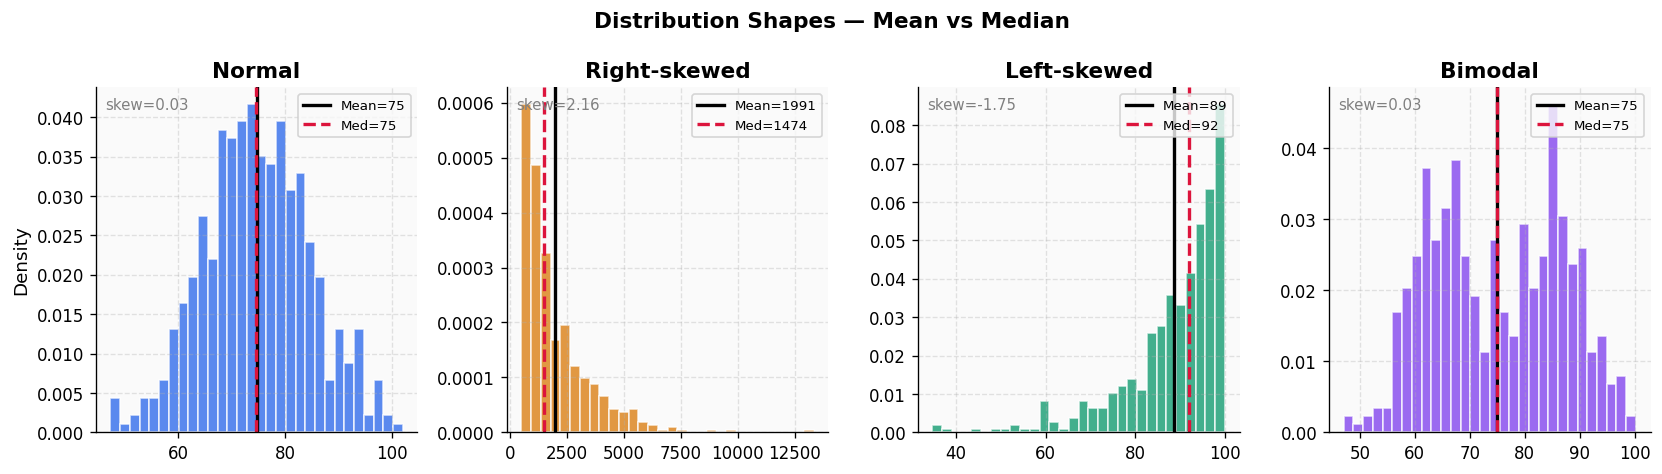

In [ ]:
# Four distribution shapes
np.random.seed(0)

# Generate example distributions
normal_data    = np.random.normal(75, 10, 500)
right_skew     = np.random.exponential(scale=1, size=500) * 1500 + 500   # income-like
left_skew      = 100 - np.random.exponential(scale=1, size=500) * 10     # near-ceiling scores
bimodal        = np.concatenate([np.random.normal(65, 6, 250),
                                  np.random.normal(85, 6, 250)])          # two groups

datasets = [
    (normal_data, 'Normal',       PALETTE['blue']),
    (right_skew,  'Right-skewed', PALETTE['amber']),
    (left_skew,   'Left-skewed',  PALETTE['green']),
    (bimodal,     'Bimodal',      PALETTE['violet']),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, (data, title, color) in zip(axes, datasets):
    ax.hist(data, bins=30, color=color, alpha=0.75, edgecolor='white', density=True)
    ax.axvline(np.mean(data),   color='black',  lw=2, ls='-',  label=f'Mean={np.mean(data):.0f}')
    ax.axvline(np.median(data), color='crimson',lw=2, ls='--', label=f'Med={np.median(data):.0f}')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    skew = stats.skew(data)
    ax.text(0.03, 0.97, f'skew={skew:.2f}', transform=ax.transAxes,
            va='top', fontsize=9, color='gray')

axes[0].set_ylabel("Density")
fig.suptitle("Distribution Shapes — Mean vs Median", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("shapes.png")
plt.show()


## 1.4 Interactive Statistics Explorer

Use the dropdown to explore summary statistics across three datasets.
Observe how the distribution shape, mean–median gap, and skewness change.


In [ ]:
from ipywidgets import interact, Dropdown, IntSlider

DATASETS = {
    'Exam Scores':         (exam_scores,   'Score',    False),
    'Rental Prices ($)':   (rental_prices, 'Price ($)', True),
    'Heights (cm)':        (heights,       'cm',       False),
}

def explore_dataset(dataset='Exam Scores', bins=15):
    data, xlabel, is_currency = DATASETS[dataset]
    color = PALETTE['blue']
    fmt = lambda v: f"${v:,.0f}" if is_currency else f"{v:.2f}"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4),
                                   gridspec_kw={'width_ratios': [2, 1]})

    # Histogram
    ax1.hist(data, bins=bins, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    ax1.axvline(np.mean(data),   color='black',  lw=2.5, ls='-',  label=f'Mean = {fmt(np.mean(data))}')
    ax1.axvline(np.median(data), color='crimson',lw=2.5, ls='--', label=f'Median = {fmt(np.median(data))}')
    ax1.set_xlabel(xlabel); ax1.set_ylabel("Count"); ax1.legend()
    ax1.set_title(f"Histogram — {dataset}")

    # Stats panel (text box)
    q1, q3 = np.percentile(data, [25, 75])
    sd = np.std(data, ddof=1)
    cv = sd / np.mean(data) * 100
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)

    stats_text = (
        f"  n            = {len(data)}\n"
        f"  Min          = {fmt(data.min())}\n"
        f"  Max          = {fmt(data.max())}\n"
        f"  Mean         = {fmt(np.mean(data))}\n"
        f"  Median       = {fmt(np.median(data))}\n"
        f"  Std Dev      = {fmt(sd)}\n"
        f"  IQR          = {fmt(q3 - q1)}\n"
        f"  CV           = {cv:.1f}%\n"
        f"  Skewness     = {skew:.3f}\n"
        f"  Kurtosis     = {kurt:.3f}"
    )
    ax2.text(0.05, 0.95, stats_text, transform=ax2.transAxes,
             fontsize=10, va='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#F0F4FF', edgecolor='#93C5FD', linewidth=1.5))
    ax2.set_axis_off()
    ax2.set_title("Computed Statistics", pad=12)

    plt.tight_layout()
    plt.show()

interact(explore_dataset,
         dataset=Dropdown(options=list(DATASETS.keys()), description='Dataset:'),
         bins=IntSlider(min=5, max=30, step=1, value=12, description='Bins:'))


interactive(children=(Dropdown(description='Dataset:', options=('Exam Scores', 'Rental Prices ($)', 'Heights (…

<function __main__.explore_dataset(dataset='Exam Scores', bins=15)>

# Exercise 1.1: Interpreting Descriptive Statistics

Using the interactive explorer above, answer the following:

1. Which dataset has the **largest gap** between mean and median? What does this tell you?
2. The exam scores have a slightly **left-skewed** distribution. Why might that be?
3. For rental prices, which measure of central tendency would you report to a potential renter and **why**?
4. Calculate the **coefficient of variation** (CV = σ/mean × 100) for each dataset. Which is most variable *relative* to its scale?

> *Hint: CV values are shown in the stats panel of the explorer above.*


---
# Unit 2 Visualization Chart Types

The right chart type reveals structure; the wrong one obscures it.
We organize charts by their **primary communicative purpose**, not by aesthetics.

### Learning objectives
- Navigate the chart taxonomy by data question, not chart name
- Build distribution, comparison, and relationship visualizations
- Choose the appropriate time-series pattern for your data
- Evaluate trade-offs between chart types for the same data


## 2.1 Chart Taxonomy — Start with Your Question

| Your question | Chart family | Best choices | Avoid |
|---------------|-------------|--------------|-------|
| How is one variable distributed? | **Distribution** | Histogram, box plot, violin | Pie for continuous data |
| How do categories compare? | **Comparison** | Bar chart, dot plot, lollipop | 3D bars, broken axes |
| What's the relationship between two variables? | **Relationship** | Scatter, bubble, heatmap | Pie, bar charts |
| How does a metric change over time? | **Temporal** | Line chart, area chart | Bar with many time periods |
| What fraction of a whole? | **Part-to-whole** | Stacked bar, treemap, waffle | Pie with >5 segments |

> **The most common mistake:** Choosing the chart type *first*, then fitting the data to it.
> Always start with your question.


## 2.2 Distribution Plots

Distribution charts answer: *"What values are common? What's rare? Are there outliers?"*

**When to use each:**
- **Histogram:** Frequency across bins. Best when n > 30. *Bin width dramatically affects interpretation.*
- **Box plot:** Ideal for comparing distributions across groups. Shows outliers explicitly.
- **Violin plot:** Combines box plot summary with density estimation — best for revealing bimodal distributions.
- **KDE (density curve):** Smoothed histogram, good for overlaying multiple distributions.


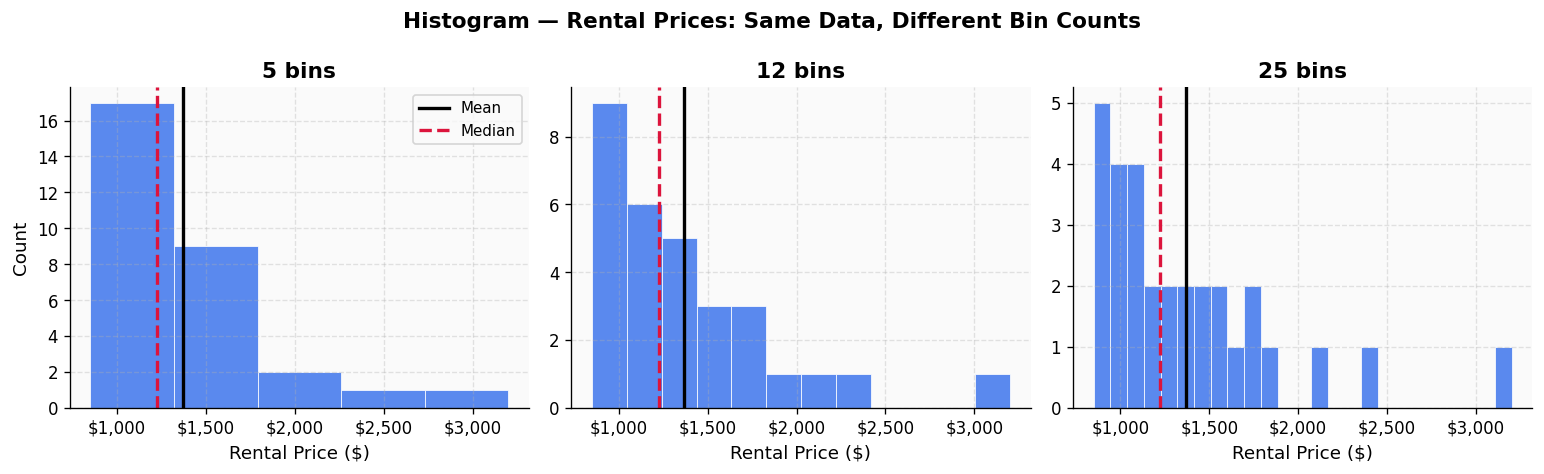

Observation: Fewer bins can hide multimodality; too many bins introduce noise.


In [ ]:
# 2.2a  Histogram — bin width effects
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

bin_counts = [5, 12, 25]
for ax, n_bins in zip(axes, bin_counts):
    ax.hist(rental_prices, bins=n_bins, color=PALETTE['blue'], alpha=0.75,
            edgecolor='white', linewidth=0.6)
    ax.axvline(np.mean(rental_prices),   color='black',  lw=2, ls='-',  label='Mean')
    ax.axvline(np.median(rental_prices), color='crimson',lw=2, ls='--', label='Median')
    ax.set_title(f'{n_bins} bins')
    ax.set_xlabel('Rental Price ($)')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[0].legend(fontsize=9)
axes[0].set_ylabel('Count')
fig.suptitle("Histogram — Rental Prices: Same Data, Different Bin Counts",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Observation: Fewer bins can hide multimodality; too many bins introduce noise.")


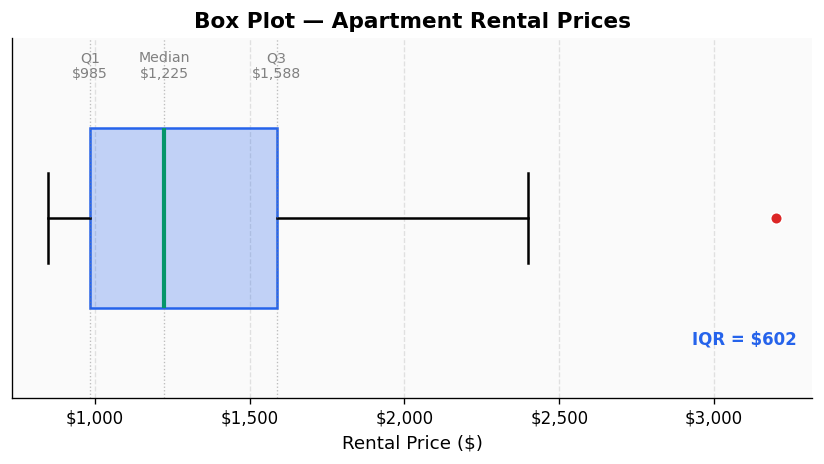

In [ ]:
# 2.2b  Box plot
fig, ax = plt.subplots(figsize=(7, 4))

bp = ax.boxplot(rental_prices, vert=False, widths=0.5, patch_artist=True,
                medianprops=dict(color=PALETTE['green'], linewidth=2.5),
                boxprops=dict(facecolor=PALETTE['blue']+'44', edgecolor=PALETTE['blue'], linewidth=1.5),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor=PALETTE['red'], markersize=7,
                                linestyle='none', markeredgecolor='white'))

q1, q2, q3 = np.percentile(rental_prices, [25, 50, 75])
iqr = q3 - q1

for val, label, offset in [(q1,'Q1',-50),(q2,'Median',0),(q3,'Q3',50)]:
    ax.axvline(val, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.text(val, 1.38, f'{label}\n${val:,.0f}', ha='center', va='bottom',
            fontsize=8.5, color='gray')

ax.text(0.98, 0.15, f'IQR = ${iqr:,.0f}', transform=ax.transAxes,
        ha='right', fontsize=10, color=PALETTE['blue'], fontweight='bold')

ax.set_yticks([])
ax.set_xlabel('Rental Price ($)')
ax.set_title('Box Plot — Apartment Rental Prices')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()


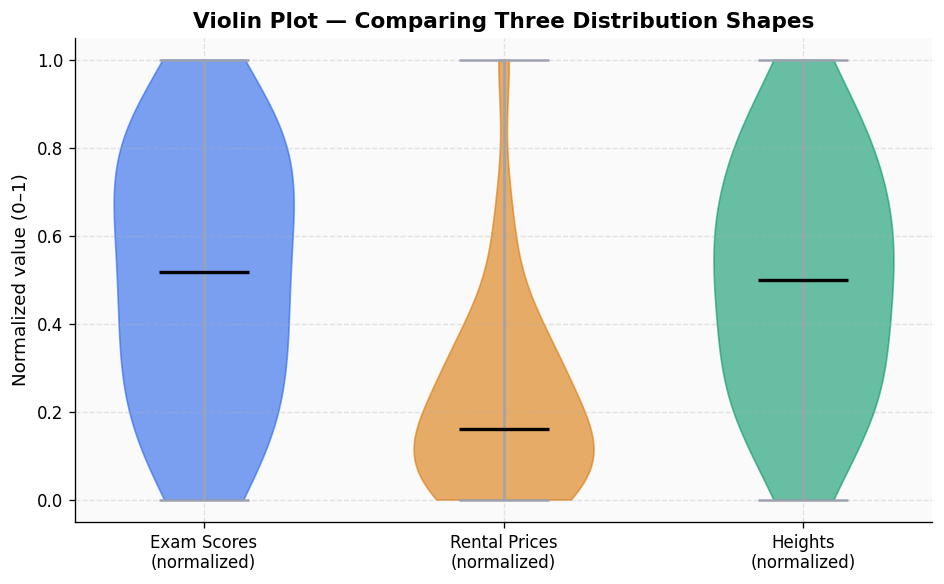

In [ ]:
# 2.2c  Violin plot — comparing three datasets
fig, ax = plt.subplots(figsize=(8, 5))

# Normalize to [0,1] so different scales can be compared visually
def norm(arr): return (arr - arr.min()) / (arr.max() - arr.min())

plot_data = [norm(exam_scores), norm(rental_prices), norm(heights)]
labels    = ['Exam Scores\n(normalized)', 'Rental Prices\n(normalized)', 'Heights\n(normalized)']
colors    = [PALETTE['blue'], PALETTE['amber'], PALETTE['green']]

parts = ax.violinplot(plot_data, positions=[1,2,3], showmedians=True,
                      showextrema=True, widths=0.6)

for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
    pc.set_edgecolor(color)

parts['cmedians'].set_edgecolor('black')
parts['cmedians'].set_linewidth(2)
parts['cmins'].set_edgecolor('#9CA3AF')
parts['cmaxes'].set_edgecolor('#9CA3AF')
parts['cbars'].set_edgecolor('#9CA3AF')

ax.set_xticks([1,2,3])
ax.set_xticklabels(labels)
ax.set_ylabel('Normalized value (0–1)')
ax.set_title('Violin Plot — Comparing Three Distribution Shapes')
plt.tight_layout()
plt.show()


## 2.3 Comparison Plots

Comparison charts answer: *"Which category is largest / fastest / most common?"*

**Key rules:**
- **Sort bars** from highest to lowest unless order has intrinsic meaning (months, age groups)
- Use **horizontal bars** when category labels are long
- Limit grouped bar charts to **≤5 series** for legibility
- **Stacked bars** are for showing totals + composition simultaneously


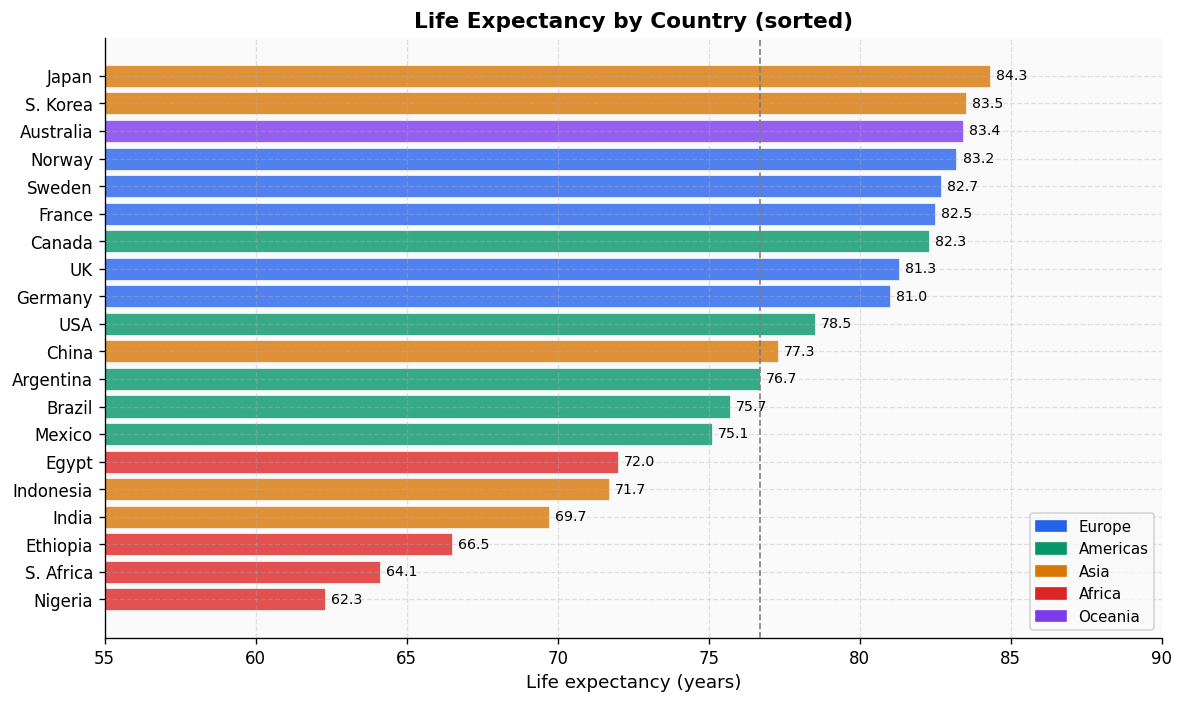

In [ ]:
# 2.3a  Sorted bar chart: Life expectancy by country
fig, ax = plt.subplots(figsize=(10, 6))

sorted_df = world_health.sort_values('life_expectancy', ascending=True)
colors_bar = [REGION_COLORS[r] for r in sorted_df['region']]

bars = ax.barh(sorted_df['country'], sorted_df['life_expectancy'],
               color=colors_bar, alpha=0.8, edgecolor='white', linewidth=0.5)

# Annotate each bar
for bar, val in zip(bars, sorted_df['life_expectancy']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=8.5)

# Legend
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLORS.items()]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')

ax.set_xlabel('Life expectancy (years)')
ax.set_title('Life Expectancy by Country (sorted)', fontweight='bold')
ax.set_xlim(55, 90)
ax.axvline(world_health['life_expectancy'].mean(), color='gray',
           linestyle='--', linewidth=1, label=f'Global mean')
plt.tight_layout()
plt.show()


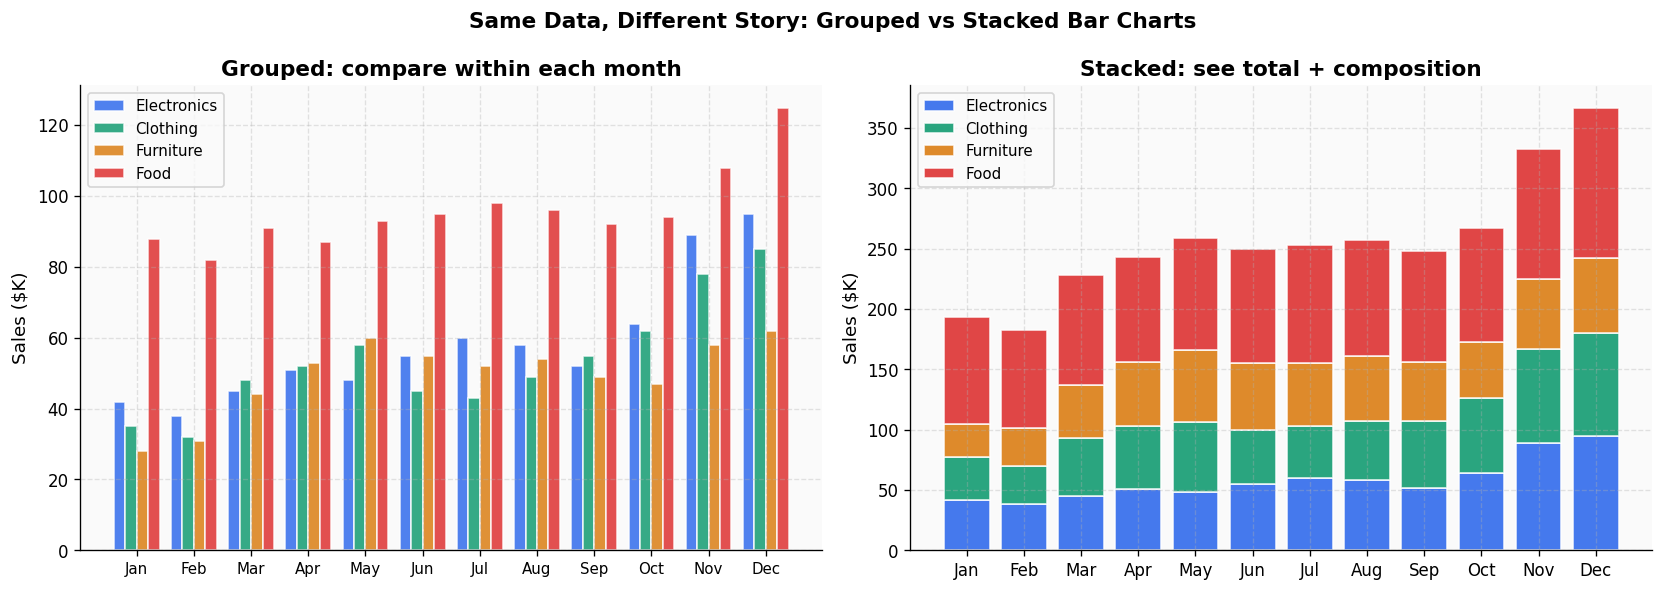

Use grouped bars when between-group comparisons matter most.
Use stacked bars when the total across categories matters.


In [ ]:
# 2.3b  Grouped vs Stacked bar — retail sales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
categories = ['electronics', 'clothing', 'furniture', 'food']
cat_colors  = [PALETTE['blue'], PALETTE['green'], PALETTE['amber'], PALETTE['red']]

x = np.arange(len(months))
width = 0.2

# Grouped
for i, (cat, color) in enumerate(zip(categories, cat_colors)):
    axes[0].bar(x + i*width, monthly_sales[cat], width,
                label=cat.title(), color=color, alpha=0.8, edgecolor='white')
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(months, fontsize=9)
axes[0].set_title('Grouped: compare within each month')
axes[0].set_ylabel('Sales ($K)')
axes[0].legend(fontsize=9)

# Stacked
bottom = np.zeros(len(months))
for cat, color in zip(categories, cat_colors):
    axes[1].bar(months, monthly_sales[cat], bottom=bottom,
                label=cat.title(), color=color, alpha=0.85, edgecolor='white')
    bottom += monthly_sales[cat].values
axes[1].set_title('Stacked: see total + composition')
axes[1].set_ylabel('Sales ($K)')
axes[1].legend(fontsize=9)

fig.suptitle('Same Data, Different Story: Grouped vs Stacked Bar Charts',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Use grouped bars when between-group comparisons matter most.")
print("Use stacked bars when the total across categories matters.")


## 2.4 Relationship Plots

Scatter plots reveal correlations, clusters, and outliers that summary statistics miss.

> **Anscombe's Quartet (1973):** Four datasets with *identical* means, variances, and correlation coefficients (r≈0.82) that look completely different when plotted. This is the canonical argument for *always visualising before analysing*.

**Bubble charts** extend scatter plots by encoding a third variable as bubble *size*.
Use with caution. Humans estimate area poorly. Always provide a size legend.


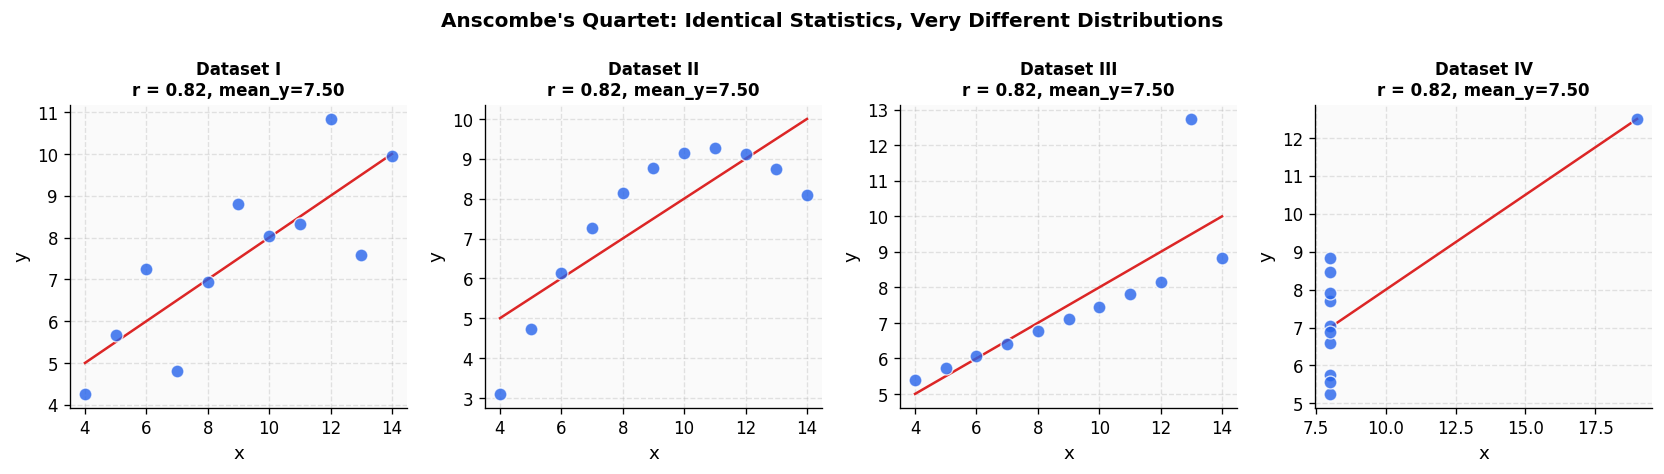

In [ ]:
# 2.4a  Anscombe's Quartet
anscombe = sns.load_dataset("anscombe")

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (dataset, group) in zip(axes, anscombe.groupby('dataset')):
    ax.scatter(group['x'], group['y'], color=PALETTE['blue'], s=60,
               alpha=0.8, edgecolors='white', linewidth=0.8, zorder=3)
    # Regression line
    m, b = np.polyfit(group['x'], group['y'], 1)
    xline = np.linspace(group['x'].min(), group['x'].max(), 100)
    ax.plot(xline, m*xline + b, color=PALETTE['red'], linewidth=1.5, zorder=2)
    r, _ = stats.pearsonr(group['x'], group['y'])
    ax.set_title(f'Dataset {dataset}\nr = {r:.2f}, mean_y={group["y"].mean():.2f}',
                 fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y')

fig.suptitle("Anscombe's Quartet: Identical Statistics, Very Different Distributions",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


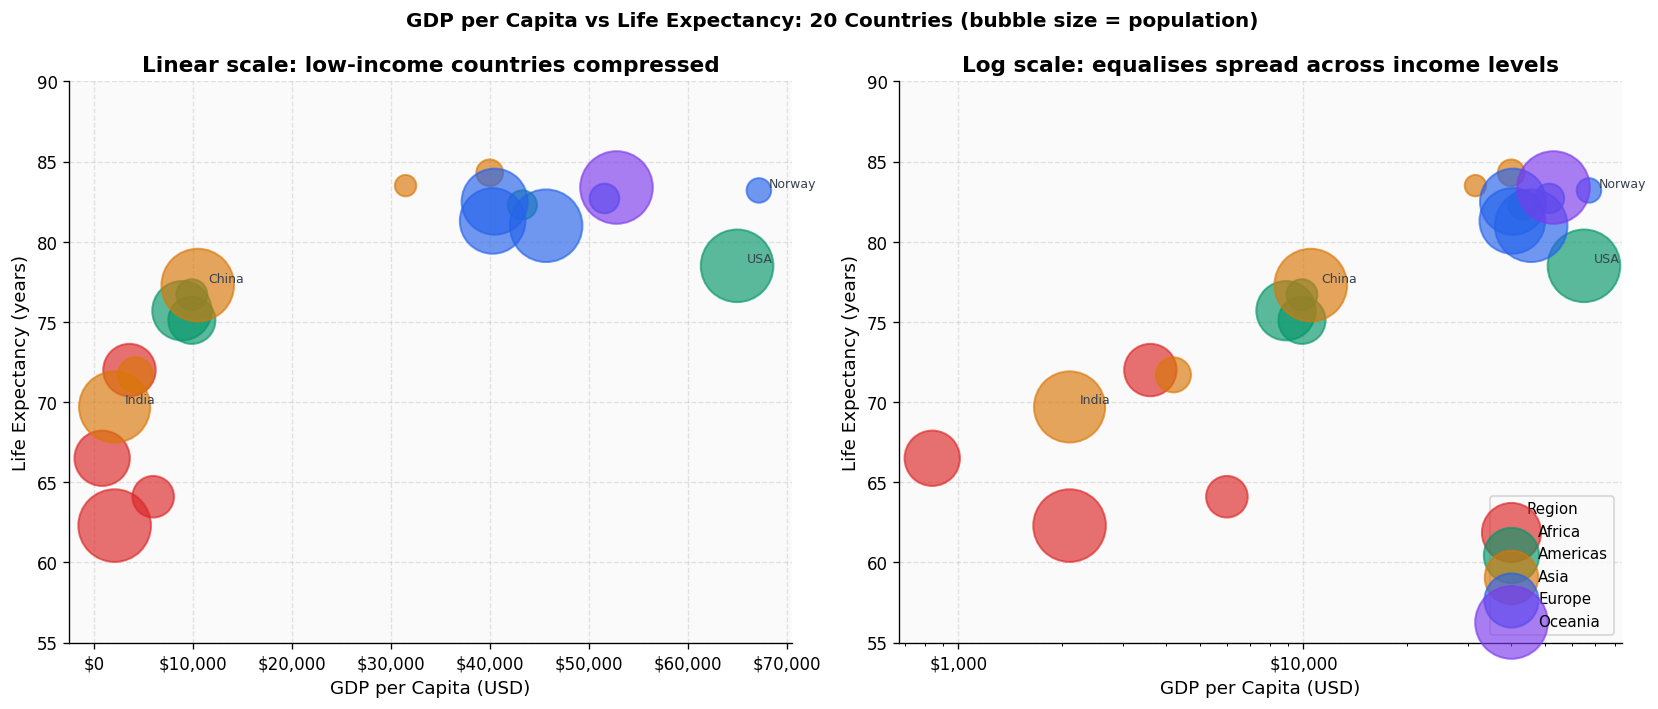

Pearson r (log GDP vs Life Expectancy) = 0.897  (p=0.0000)


In [ ]:
# 2.4b  Bubble chart — GDP vs Life Expectancy
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, log_scale in zip(axes, [False, True]):
    for region, group in world_health.groupby('region'):
        sizes = (group['population_M'] / group['population_M'].max()) * 1800 + 100
        ax.scatter(group['gdp_per_capita'], group['life_expectancy'],
                   s=sizes, color=REGION_COLORS[region], alpha=0.65,
                   edgecolors=REGION_COLORS[region], linewidth=1.2,
                   label=region, zorder=3)
        # Country labels for notable outliers
        for _, row in group.iterrows():
            if row['population_M'] > 300 or row['gdp_per_capita'] > 60000:
                ax.annotate(row['country'],
                            (row['gdp_per_capita'], row['life_expectancy']),
                            xytext=(6, 2), textcoords='offset points', fontsize=7.5,
                            color='#374151')

    if log_scale:
        ax.set_xscale('log')
        ax.set_title('Log scale: equalises spread across income levels')
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    else:
        ax.set_title('Linear scale: low-income countries compressed')
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    ax.set_xlabel('GDP per Capita (USD)')
    ax.set_ylabel('Life Expectancy (years)')
    ax.set_ylim(55, 90)

# Shared legend
handles, labels_leg = axes[0].get_legend_handles_labels()
unique = dict(zip(labels_leg, handles))
axes[1].legend(unique.values(), unique.keys(), fontsize=9, loc='lower right',
               title='Region', title_fontsize=9)

fig.suptitle("GDP per Capita vs Life Expectancy: 20 Countries (bubble size = population)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation
r, p = stats.pearsonr(np.log(world_health['gdp_per_capita']), world_health['life_expectancy'])
print(f"Pearson r (log GDP vs Life Expectancy) = {r:.3f}  (p={p:.4f})")


# Exercise 2.1: Interpreting the Scatter Plot

1. **Which country** has a higher life expectancy than its GDP would predict? What might explain this?
2. **Which region** shows the greatest *within-region* variation in life expectancy?
3. Switch to log scale: how does Norway's position change relative to its neighbors?
4. What type of correlation (positive, negative, none) do you observe? Is it linear?


## 2.5 Time Series

Time-series data has a special structure: the **order** of data points encodes meaning.

**Use line charts when** the trend *between* points is meaningful (continuous process).
**Use bar charts when** points are independent discrete categories that happen to be ordered.

**Time series patterns to annotate explicitly:**
- **Trend**: long-run directional change $\rightarrow$ add trend line
- **Seasonality**: repeating cycles $\rightarrow$ note the period
- **Changepoints**: sudden shifts $\rightarrow$ vertical reference line + label
- **Anomalies**: values far from expected $\rightarrow$ highlight and name them


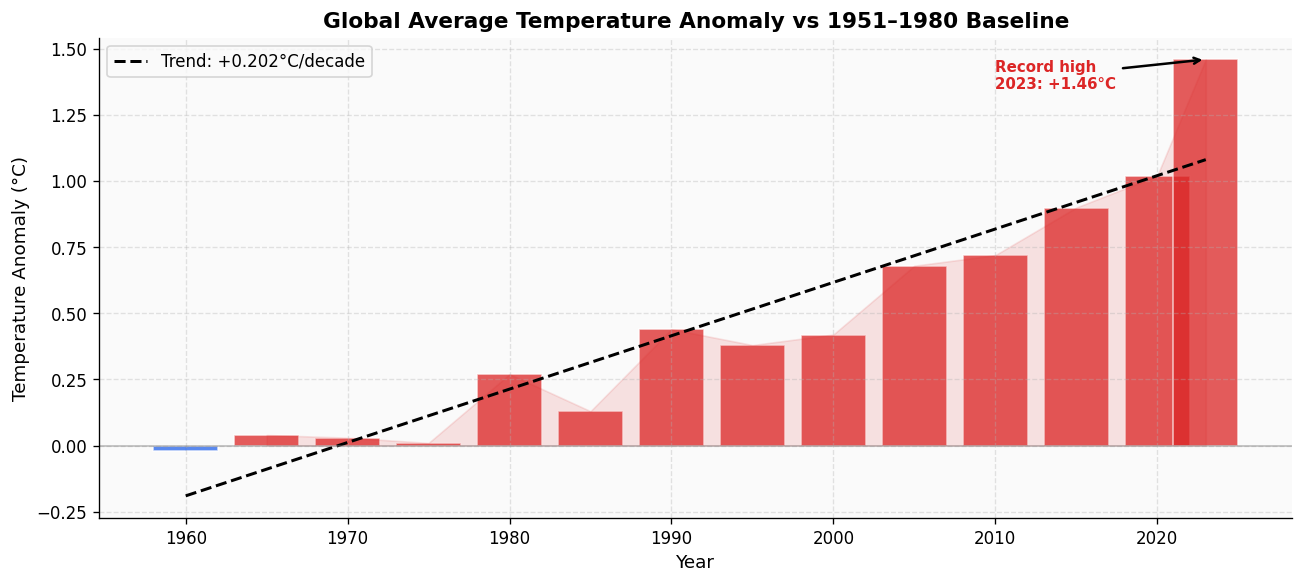

In [ ]:
# 2.5a  Temperature anomaly — annotated time series
fig, ax = plt.subplots(figsize=(11, 5))

# Color bars by positive/negative
colors_bar = [PALETTE['red'] if v > 0 else PALETTE['blue']
              for v in temp_data['anomaly']]
ax.bar(temp_data['year'], temp_data['anomaly'], color=colors_bar,
       alpha=0.75, width=4, edgecolor='white')

# Trend line
z = np.polyfit(temp_data['year'], temp_data['anomaly'], 1)
p_line = np.poly1d(z)
x_trend = np.linspace(temp_data['year'].min(), temp_data['year'].max(), 100)
ax.plot(x_trend, p_line(x_trend), color='black', linewidth=1.8,
        linestyle='--', label=f'Trend: +{z[0]*10:.3f}°C/decade')

# Reference line at 0
ax.axhline(0, color='gray', linewidth=1, linestyle='-', alpha=0.5)

# Annotations
ax.annotate('Record high\n2023: +1.46°C',
            xy=(2023, 1.46), xytext=(2010, 1.35),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
            fontsize=9, color=PALETTE['red'], fontweight='bold')

ax.fill_between(temp_data['year'], temp_data['anomaly'], 0,
                where=(temp_data['anomaly'] > 0),
                alpha=0.12, color=PALETTE['red'])
ax.fill_between(temp_data['year'], temp_data['anomaly'], 0,
                where=(temp_data['anomaly'] <= 0),
                alpha=0.12, color=PALETTE['blue'])

ax.set_xlabel('Year')
ax.set_ylabel('Temperature Anomaly (°C)')
ax.set_title('Global Average Temperature Anomaly vs 1951–1980 Baseline',
             fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


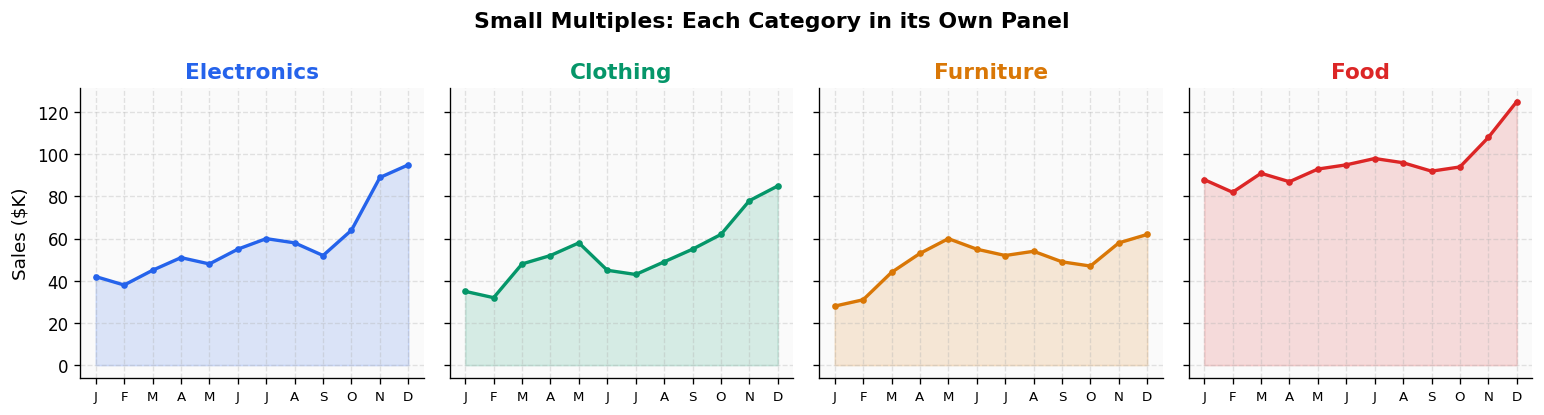

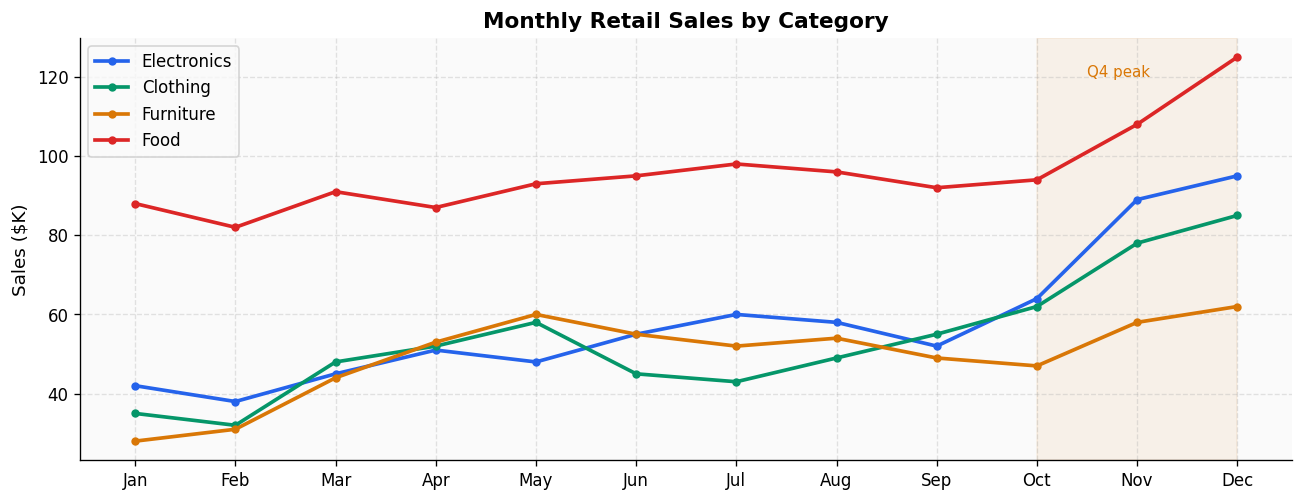

In [ ]:
# 2.5b  Monthly retail sales — multi-series line + seasonality
fig, axes = plt.subplots(2, 1, figsize=(11, 8))

# Top: full multi-line chart
cat_colors_dict = dict(zip(
    ['electronics','clothing','furniture','food'],
    [PALETTE['blue'], PALETTE['green'], PALETTE['amber'], PALETTE['red']]
))
for cat, color in cat_colors_dict.items():
    axes[0].plot(months, monthly_sales[cat], marker='o', markersize=4,
                 linewidth=2.2, color=color, label=cat.title())
axes[0].set_title('Monthly Retail Sales by Category')
axes[0].set_ylabel('Sales ($K)')
axes[0].legend(fontsize=10)
axes[0].axvspan(9, 11, alpha=0.07, color=PALETTE['amber'], label='Q4 peak')
axes[0].text(9.5, 120, 'Q4 peak', fontsize=9, color=PALETTE['amber'])

# Bottom: small multiples
for i, (cat, color) in enumerate(cat_colors_dict.items()):
    ax = axes[1] if i == 0 else None
# Use a proper subplot grid for small multiples
fig2, ax2s = plt.subplots(1, 4, figsize=(13, 3.5), sharey=True)
for ax_s, (cat, color) in zip(ax2s, cat_colors_dict.items()):
    ax_s.plot(months, monthly_sales[cat], marker='o', markersize=3,
              linewidth=2, color=color)
    ax_s.fill_between(range(len(months)), monthly_sales[cat],
                      alpha=0.15, color=color)
    ax_s.set_title(cat.title(), fontweight='bold', color=color)
    ax_s.set_xticks(range(len(months)))
    ax_s.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=8)

ax2s[0].set_ylabel('Sales ($K)')
fig2.suptitle('Small Multiples: Each Category in its Own Panel', fontweight='bold')

plt.figure(fig.number)
axes[1].set_visible(False)
fig.tight_layout()
fig2.tight_layout()
plt.show()


---
# Unit 3 Conveying Insights Effectively

A chart that is technically correct but visually confusing has failed.
This unit covers the perceptual and design principles that separate charts people
*actually understand* from those they merely tolerate.

### Learning objectives
- Understand preattentive attributes and how the eye processes visuals
- Apply color strategically: encode meaning, not decoration
- Identify and fix the 6 most common visualization mistakes


## 3.1 Preattentive Attributes

Certain visual properties are processed **before conscious attention** — in under 250ms.

**Hierarchy of perceptual accuracy (Cleveland & McGill, 1984):**

1. Position on common scale *(bar charts: most accurate)*
2. Position on non-aligned scale
3. Length
4. Angle *(pie charts: poor)*
5. Area *(bubble charts: overestimated)*
6. Volume *(3D charts: worst)*
7. Color saturation / hue *(for categorical, not quantitative)*

> This is why bar charts almost always outperform pie charts for quantitative comparison.


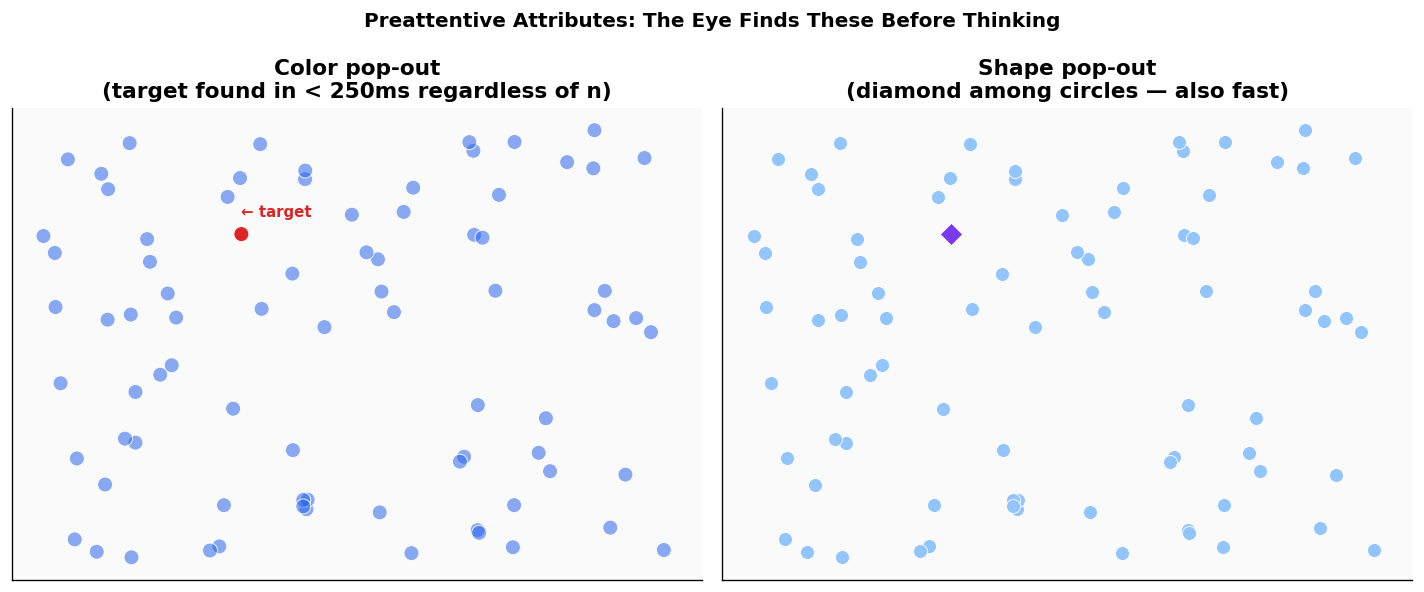

In [ ]:
# 3.1  Demonstrating preattentive processing — "pop-out" effect
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

np.random.seed(1)
n = 80
x = np.random.uniform(0, 10, n)
y = np.random.uniform(0, 10, n)
highlight_idx = 35  # one outlier

# Left: Color pop-out
colors_l = [PALETTE['red'] if i == highlight_idx else PALETTE['blue'] + '88'
            for i in range(n)]
axes[0].scatter(x, y, c=colors_l, s=80, edgecolors='white', linewidths=0.5, zorder=3)
axes[0].set_title('Color pop-out\n(target found in < 250ms regardless of n)',
                  fontweight='bold')
axes[0].text(x[highlight_idx], y[highlight_idx]+0.4, '← target', fontsize=9,
             color=PALETTE['red'], fontweight='bold')

# Right: Shape pop-out
markers = ['D' if i == highlight_idx else 'o' for i in range(n)]
for i, (xi, yi, m) in enumerate(zip(x, y, markers)):
    color = PALETTE['violet'] if i == highlight_idx else '#93C5FD'
    axes[1].scatter(xi, yi, marker=m, s=90 if m=='D' else 70,
                    c=color, edgecolors='white', linewidths=0.5, zorder=3)
axes[1].set_title('Shape pop-out\n(diamond among circles — also fast)',
                  fontweight='bold')

for ax in axes:
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.5, 10.5)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle('Preattentive Attributes: The Eye Finds These Before Thinking',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 3.2 Color Strategy: Encode Meaning, Not Decoration

| Color type | When to use | Example |
|-----------|-------------|---------|
| **Sequential** | Continuous data, one direction | Temperature maps, revenue density |
| **Diverging** | Values around a meaningful midpoint | Profit/loss, temperature anomaly |
| **Categorical** | Distinct, unordered groups | Product categories, regions |

**Rules:**
- Use a **muted gray** for baseline and a **vivid accent** for the key finding
- Test your chart in **grayscale**. If it still works, you're encoding well
- Use perceptually uniform scales: `viridis`, `cividis`, `RdBu`
- Never use rainbow/jet for continuous data — misleads pattern detection
- ~8% of men are red-green colorblind — always pair color with shape or texture


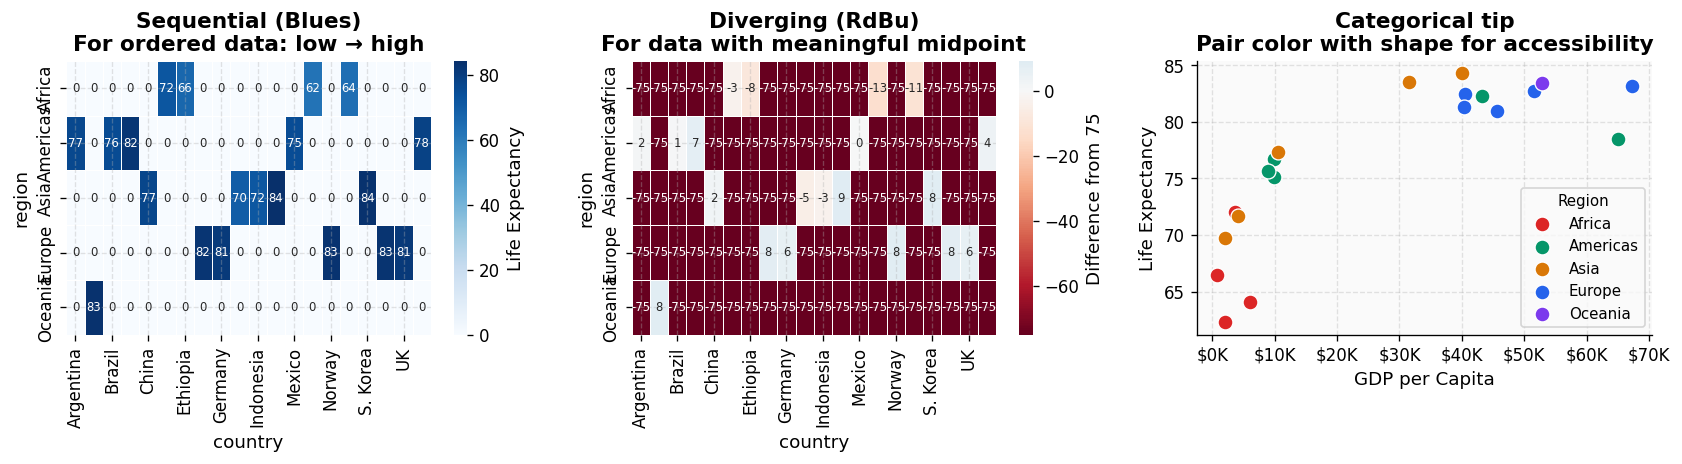

In [ ]:
# 3.2  Three color scale types on the same data
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Life expectancy matrix (sorted by region for structure)
pivot = world_health.pivot_table(index='region', columns='country',
                                  values='life_expectancy', aggfunc='first')
pivot = pivot.fillna(0)

# Sequential
sns.heatmap(pivot, ax=axes[0], cmap='Blues', linewidths=0.3,
            linecolor='white', annot=True, fmt='.0f', annot_kws={'size':7},
            cbar_kws={'label': 'Life Expectancy'})
axes[0].set_title('Sequential (Blues)\nFor ordered data: low → high')

# Diverging (centered at 75)
diff_from_75 = pivot - 75
sns.heatmap(diff_from_75, ax=axes[1], cmap='RdBu', center=0, linewidths=0.3,
            linecolor='white', annot=True, fmt='.0f', annot_kws={'size':7},
            cbar_kws={'label': 'Difference from 75'})
axes[1].set_title('Diverging (RdBu)\nFor data with meaningful midpoint')

# Categorical — use shape + color, not heatmap
axes[2].set_title('Categorical tip\nPair color with shape for accessibility')
for region, group in world_health.groupby('region'):
    axes[2].scatter(group['gdp_per_capita'], group['life_expectancy'],
                    color=REGION_COLORS[region], label=region,
                    s=80, edgecolors='white', linewidths=0.8, zorder=3,
                    marker='o')
axes[2].set_xlabel('GDP per Capita')
axes[2].set_ylabel('Life Expectancy')
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[2].legend(fontsize=9, title='Region', title_fontsize=9)

plt.tight_layout()
plt.show()


## 3.3 Common Mistakes: Before & After

Each example shows the same data visualised poorly and correctly.
The mistake in each case is **structural**, not merely aesthetic.


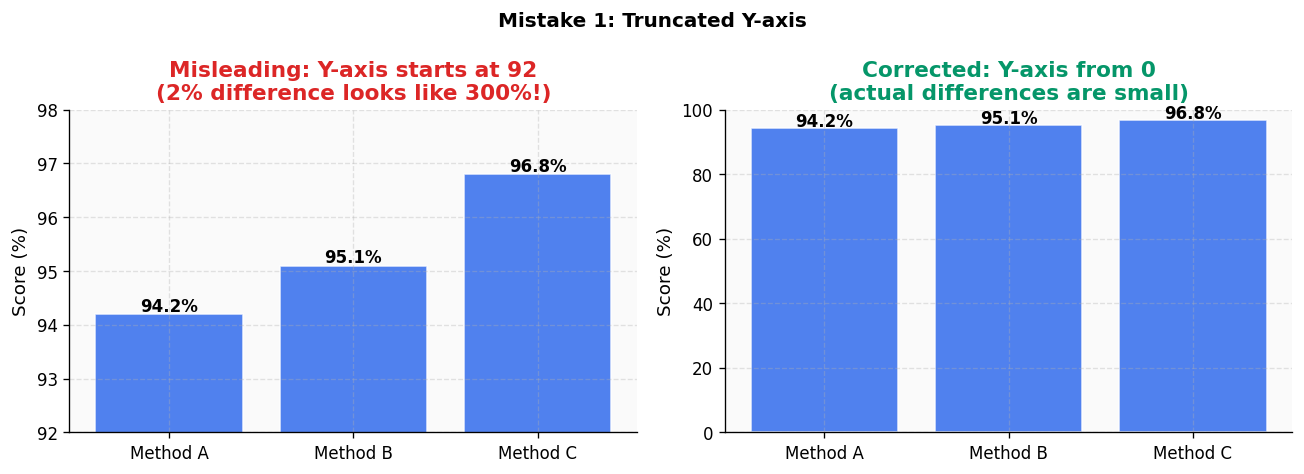

In [ ]:
# 3.3a  Truncated Y-axis
labels_ba = ['Method A', 'Method B', 'Method C']
values_ba = [94.2, 95.1, 96.8]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Misleading: truncated at 92
axes[0].bar(labels_ba, values_ba, color=[PALETTE['blue']]*3,
            alpha=0.8, edgecolor='white')
axes[0].set_ylim(92, 98)
axes[0].set_title('Misleading: Y-axis starts at 92\n(2% difference looks like 300%!)',
                   color=PALETTE['red'], fontweight='bold')
axes[0].set_ylabel('Score (%)')
for i, v in enumerate(values_ba):
    axes[0].text(i, v+0.05, f'{v}%', ha='center', fontsize=10, fontweight='bold')

# Corrected: full scale
axes[1].bar(labels_ba, values_ba, color=[PALETTE['blue']]*3,
            alpha=0.8, edgecolor='white')
axes[1].set_ylim(0, 100)
axes[1].set_title('Corrected: Y-axis from 0\n(actual differences are small)',
                   color=PALETTE['green'], fontweight='bold')
axes[1].set_ylabel('Score (%)')
for i, v in enumerate(values_ba):
    axes[1].text(i, v+0.5, f'{v}%', ha='center', fontsize=10, fontweight='bold')

fig.suptitle('Mistake 1: Truncated Y-axis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


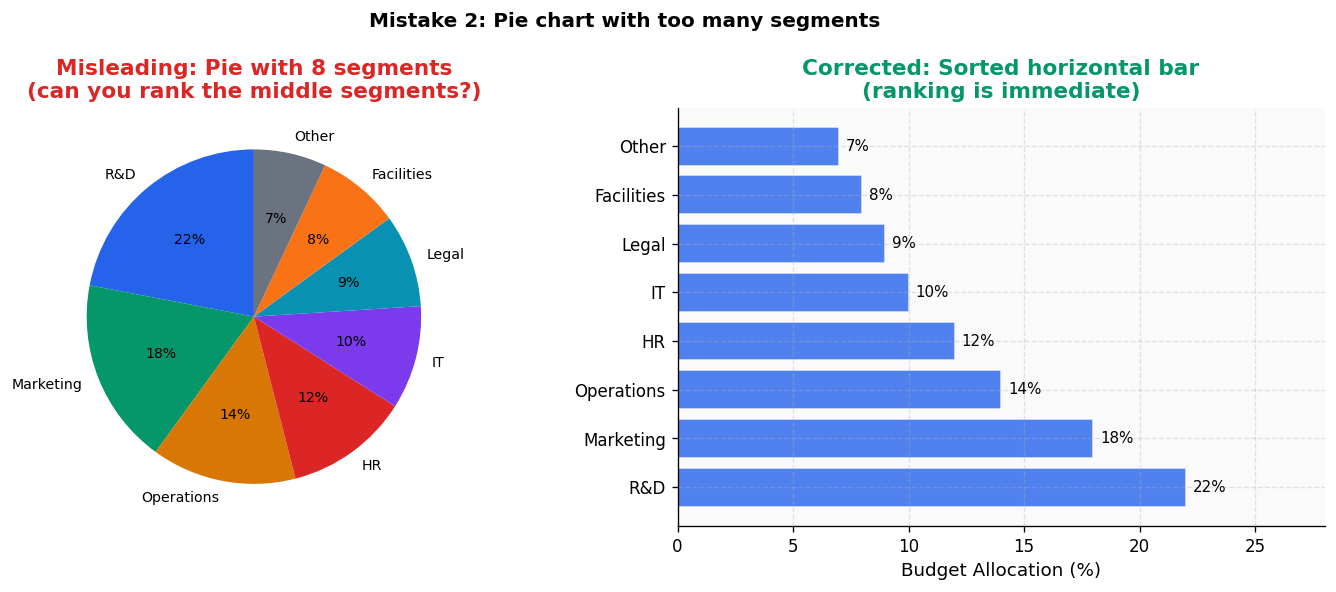

In [ ]:
# 3.3b  Pie chart vs horizontal bar
budget_labels = ['R&D','Marketing','Operations','HR','IT','Legal','Facilities','Other']
budget_values = [22, 18, 14, 12, 10, 9, 8, 7]
budget_colors = [PALETTE['blue'], PALETTE['green'], PALETTE['amber'], PALETTE['red'],
                 PALETTE['violet'], PALETTE['cyan'], PALETTE['orange'], PALETTE['gray']]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Misleading: pie with 8 segments
axes[0].pie(budget_values, labels=budget_labels, colors=budget_colors,
            autopct='%1.0f%%', startangle=90,
            textprops={'fontsize': 8.5})
axes[0].set_title('Misleading: Pie with 8 segments\n(can you rank the middle segments?)',
                   color=PALETTE['red'], fontweight='bold')

# Corrected: sorted horizontal bar
sorted_pairs = sorted(zip(budget_values, budget_labels), reverse=True)
vals_s, labs_s = zip(*sorted_pairs)
bars_s = axes[1].barh(labs_s, vals_s, color=PALETTE['blue'],
                       alpha=0.8, edgecolor='white')
for bar, val in zip(bars_s, vals_s):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=9)
axes[1].set_xlabel('Budget Allocation (%)')
axes[1].set_title('Corrected: Sorted horizontal bar\n(ranking is immediate)',
                   color=PALETTE['green'], fontweight='bold')
axes[1].set_xlim(0, 28)

fig.suptitle('Mistake 2: Pie chart with too many segments', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


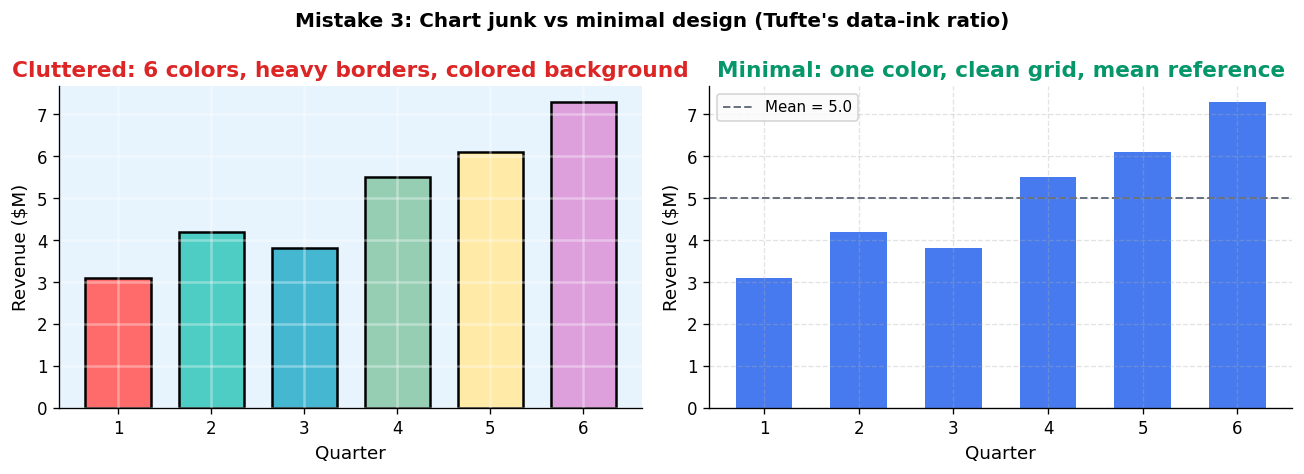

In [ ]:
# 3.3c  Chart junk vs minimal design
x_vals = range(1, 7)
y_vals = [3.1, 4.2, 3.8, 5.5, 6.1, 7.3]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Cluttered (simulated "chart junk")
axes[0].set_facecolor('#E8F4FD')
axes[0].bar(x_vals, y_vals, color=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#DDA0DD'],
            edgecolor='black', linewidth=1.5, width=0.7)
axes[0].set_title('Cluttered: 6 colors, heavy borders, colored background',
                   color=PALETTE['red'], fontweight='bold')
axes[0].grid(True, linewidth=1.5, color='white', linestyle='-')
axes[0].set_xlabel('Quarter'); axes[0].set_ylabel('Revenue ($M)')

# Clean minimal
axes[1].bar(x_vals, y_vals, color=PALETTE['blue'], alpha=0.85, edgecolor='none', width=0.6)
axes[1].axhline(np.mean(y_vals), color=PALETTE['gray'], linewidth=1.2,
                linestyle='--', label=f'Mean = {np.mean(y_vals):.1f}')
axes[1].set_facecolor('white')
axes[1].spines[['top','right']].set_visible(False)
axes[1].set_title('Minimal: one color, clean grid, mean reference',
                   color=PALETTE['green'], fontweight='bold')
axes[1].set_xlabel('Quarter'); axes[1].set_ylabel('Revenue ($M)')
axes[1].legend(fontsize=9)

fig.suptitle("Mistake 3: Chart junk vs minimal design (Tufte's data-ink ratio)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


# Exercise 3.1: Critique and Fix a Visualization

For each scenario below, describe: (a) the mistake, (b) the misleading story it tells, (c) the fix.

1. A line chart shows "customer satisfaction: 94.2% $\rightarrow$ 94.8%" with Y-axis from 94 to 95, titled **"30% improvement in satisfaction"**
2. A pie chart has 12 slices showing budget allocation, with a **3D perspective** applied
3. A **rainbow colormap** is applied to a heatmap showing temperature change over a region

*Bonus: reproduce one of these mistakes in Python, then fix it.*


---
# Unit 4 Communicating with Stakeholders

A technically perfect chart shown to the wrong audience, in the wrong context,
with the wrong framing, will fail. This unit is about the **human side** of data communication.

### Learning objectives
- Map stakeholder needs to the right visualization depth and format
- Apply the data story arc: Context $\rightarrow$ Tension $\rightarrow$ Insight $\rightarrow$ Action
- Design dashboards for different consumption contexts


## 4.1 Know Your Audience

| Audience | Time | Wants | Best format |
|---------|------|-------|-------------|
| **Executive / C-Suite** | 30 seconds | Trend direction, KPI status, exceptions | KPI cards, single-metric dashboards |
| **Manager / Analyst** | 10 minutes | Decomposition, comparison, drill-down | Comparative charts, time series, breakdowns |
| **Data Scientist** | Hours | Distributions, correlations, diagnostics | Scatter plots, histograms, heatmaps, residuals |

> **The audience test:** Before finalising a visualization, ask: *"What action do I want the reader to take?"*
> If you can't answer that, the chart isn't ready.


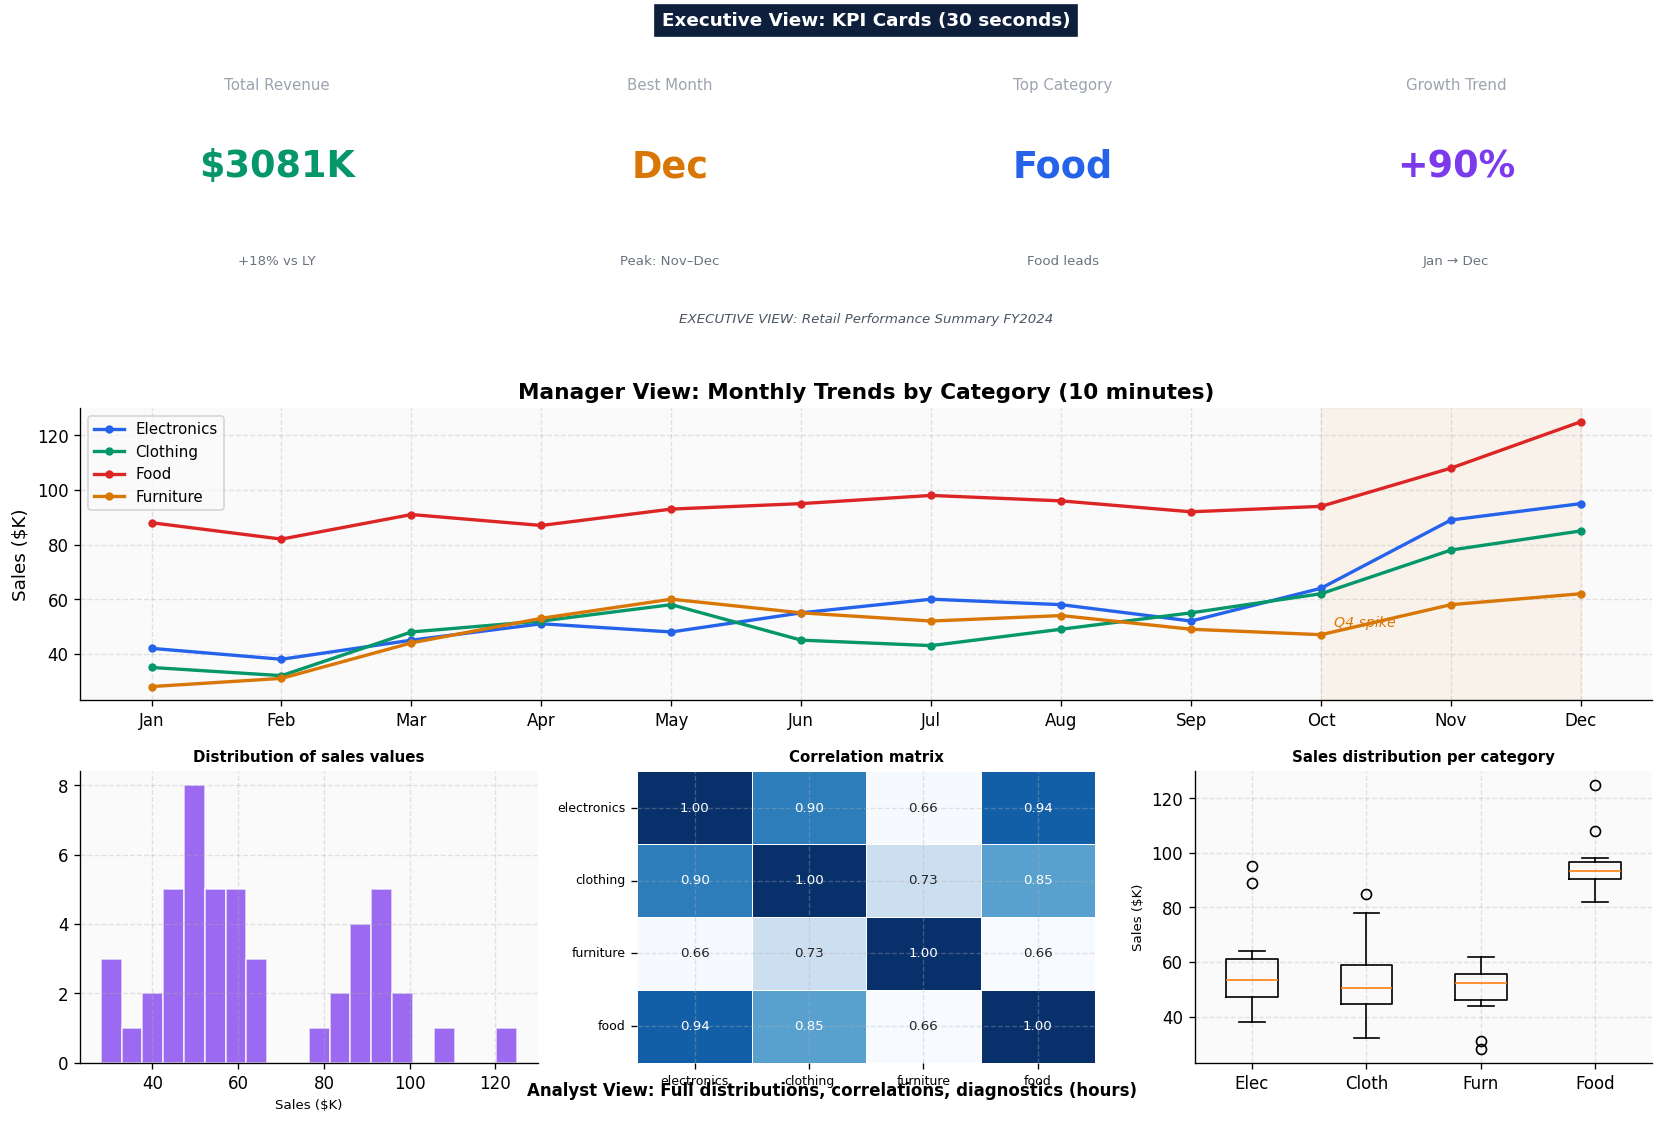

In [ ]:
# 4.1  Same data, three audience formats
total_by_month = monthly_sales[['electronics','clothing','furniture','food']].sum(axis=1)
yoy_change = ((total_by_month.iloc[-1] - total_by_month.iloc[0]) / total_by_month.iloc[0] * 100)
best_month = months[total_by_month.argmax()]
best_cat   = monthly_sales[['electronics','clothing','furniture','food']].sum().idxmax()

fig = plt.figure(figsize=(14, 10))

# Executive view: KPI tiles
ax_exec = fig.add_subplot(3, 3, (1, 3))
ax_exec.set_facecolor('#0E1F3B')
ax_exec.set_xlim(0, 4); ax_exec.set_ylim(0, 1)
ax_exec.axis('off')

kpis = [
    ('Total Revenue',  f'${total_by_month.sum():.0f}K', '+18% vs LY', PALETTE['green']),
    ('Best Month',     best_month,                        'Peak: Nov–Dec',  PALETTE['amber']),
    ('Top Category',   best_cat.title(),                  'Food leads',    PALETTE['blue']),
    ('Growth Trend',   f'+{yoy_change:.0f}%',             'Jan → Dec',     PALETTE['violet']),
]
for i, (label, value, sub, color) in enumerate(kpis):
    x = i * 1.0 + 0.5
    ax_exec.text(x, 0.85, label, ha='center', fontsize=9, color='#9CA3AF', fontweight='500')
    ax_exec.text(x, 0.55, value, ha='center', fontsize=22, color=color,   fontweight='bold')
    ax_exec.text(x, 0.25, sub,   ha='center', fontsize=8,  color='#6B7280')

ax_exec.text(0.5, 0.05, 'EXECUTIVE VIEW: Retail Performance Summary FY2024',
             ha='center', transform=ax_exec.transAxes, fontsize=8,
             color='#4B5563', style='italic')
ax_exec.set_title('Executive View: KPI Cards (30 seconds)',
                  fontweight='bold', color='white', pad=12, fontsize=11,
                  backgroundcolor='#0E1F3B')

# Manager view: trend by category
ax_mgr = fig.add_subplot(3, 1, 2)
for cat, color in [('electronics', PALETTE['blue']), ('clothing', PALETTE['green']),
                   ('food', PALETTE['red']), ('furniture', PALETTE['amber'])]:
    ax_mgr.plot(months, monthly_sales[cat], marker='o', markersize=4,
                linewidth=2, color=color, label=cat.title())
ax_mgr.set_title('Manager View: Monthly Trends by Category (10 minutes)', fontweight='bold')
ax_mgr.set_ylabel('Sales ($K)'); ax_mgr.legend(fontsize=9)
ax_mgr.axvspan(9, 11, alpha=0.06, color=PALETTE['amber'])
ax_mgr.text(9.1, 50, 'Q4 spike', fontsize=8.5, color=PALETTE['amber'], fontstyle='italic')

# Analyst view: distribution + correlation
ax_ana1 = fig.add_subplot(3, 3, 7)
long_sales = monthly_sales[['electronics','clothing','furniture','food']].values.flatten()
ax_ana1.hist(long_sales, bins=20, color=PALETTE['violet'], alpha=0.75, edgecolor='white')
ax_ana1.set_title('Distribution of sales values', fontsize=9, fontweight='bold')
ax_ana1.set_xlabel('Sales ($K)', fontsize=8)

ax_ana2 = fig.add_subplot(3, 3, 8)
corr = monthly_sales[['electronics','clothing','furniture','food']].corr()
sns.heatmap(corr, ax=ax_ana2, cmap='Blues', annot=True, fmt='.2f',
            annot_kws={'size':8}, linewidths=0.3, cbar=False)
ax_ana2.set_title('Correlation matrix', fontsize=9, fontweight='bold')
ax_ana2.tick_params(labelsize=7.5)

ax_ana3 = fig.add_subplot(3, 3, 9)
monthly_sales_melt = monthly_sales.melt(id_vars='month', var_name='category', value_name='sales')
ax_ana3.boxplot([monthly_sales[c] for c in ['electronics','clothing','furniture','food']],
                labels=['Elec','Cloth','Furn','Food'])
ax_ana3.set_title('Sales distribution per category', fontsize=9, fontweight='bold')
ax_ana3.set_ylabel('Sales ($K)', fontsize=8)

fig.text(0.5, 0.08, 'Analyst View: Full distributions, correlations, diagnostics (hours)',
         ha='center', fontsize=10, fontweight='bold')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


## 4.2 Data Storytelling: From Numbers to Narrative

A data **story** makes the audience care about the data.
A data **presentation** just shows it. The structure is always the same:

1. Context   $\rightarrow$ Orient the audience. What's the baseline? What's normal?
2. Tension   $\rightarrow$ What's the problem, anomaly, or opportunity?
3. Insight   $\rightarrow$ What does the data say about WHY the tension exists?
4. Action    $\rightarrow$ What should the audience DO next?


> **Weak:** *"Here is our monthly user acquisition chart for the past year."*
>
> **Strong:** *"User acquisition grew steadily through Q1–Q2, but stalled in August;
> the same month we paused paid campaigns. Our organic growth alone maintained the Q1 rate,
> suggesting paid spend was masking weak retention. I recommend we investigate cohort
> retention before scaling ad spend."*


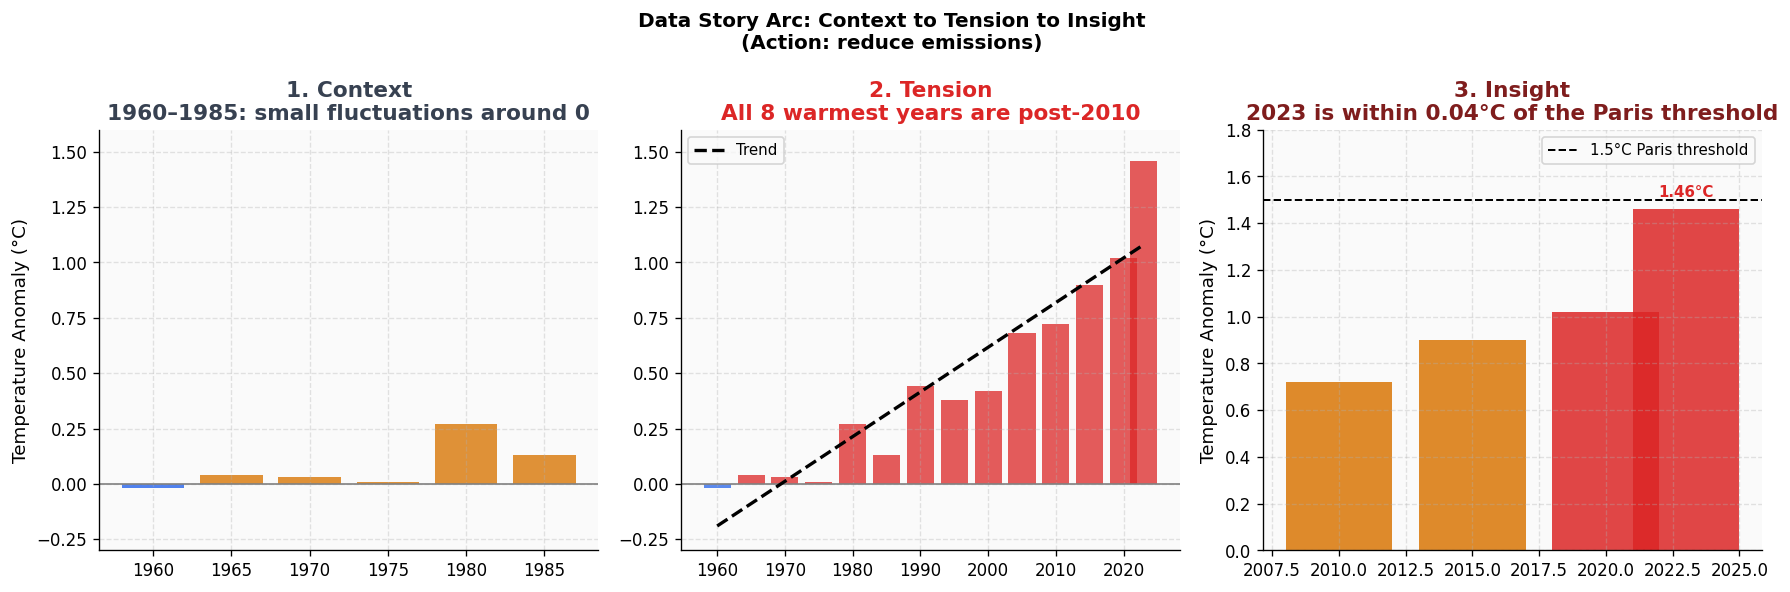

In [ ]:
# 4.2  Build a 3-chart narrative from the temperature data

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: CONTEXT: the baseline period
baseline = temp_data[temp_data['year'] <= 1985]
axes[0].bar(baseline['year'], baseline['anomaly'],
            color=[PALETTE['blue'] if v <= 0 else PALETTE['amber'] for v in baseline['anomaly']],
            alpha=0.8, width=4)
axes[0].axhline(0, color='gray', linewidth=1)
axes[0].set_ylim(-0.3, 1.6)
axes[0].set_title('1. Context\n1960–1985: small fluctuations around 0',
                   fontweight='bold', color='#374151')
axes[0].set_ylabel('Temperature Anomaly (°C)')

# Chart 2: TENSION: the trend emerging
axes[1].bar(temp_data['year'], temp_data['anomaly'],
            color=[PALETTE['blue'] if v <= 0 else PALETTE['red'] for v in temp_data['anomaly']],
            alpha=0.75, width=4)
axes[1].axhline(0, color='gray', linewidth=1)
z = np.polyfit(temp_data['year'], temp_data['anomaly'], 1)
p_line = np.poly1d(z)
xr = np.linspace(1960, 2023, 100)
axes[1].plot(xr, p_line(xr), 'k--', linewidth=2, label='Trend')
axes[1].set_ylim(-0.3, 1.6)
axes[1].set_title('2. Tension\nAll 8 warmest years are post-2010',
                   fontweight='bold', color=PALETTE['red'])
axes[1].legend(fontsize=9)

# Chart 3: INSIGHT: magnitude matters
recent = temp_data[temp_data['year'] >= 2010]
colors_i = [PALETTE['amber'] if v < 1.0 else PALETTE['red'] for v in recent['anomaly']]
bars_i = axes[2].bar(recent['year'], recent['anomaly'],
                     color=colors_i, alpha=0.85, width=4)
axes[2].axhline(1.5, color='black', linewidth=1.2, linestyle='--',
                label='1.5°C Paris threshold')
axes[2].set_ylim(0, 1.8)
axes[2].set_title('3. Insight\n2023 is within 0.04°C of the Paris threshold',
                   fontweight='bold', color='#7f1d1d')
axes[2].set_ylabel('Temperature Anomaly (°C)')
axes[2].legend(fontsize=9)
axes[2].text(2023, 1.50, '1.46°C', ha='center', va='bottom', fontsize=9,
             fontweight='bold', color=PALETTE['red'])

fig.suptitle('Data Story Arc: Context to Tension to Insight\n(Action: reduce emissions)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
# Unit 5 Hands-On Workshop

Apply everything from Units 1-4 to two real-world datasets. Your goal is not just to
make charts. It is to **find and communicate a meaningful insight**.


## Exercise 1 · Global Health & Development

**Dataset:** `world_health`: 20 countries, variables: GDP per capita, life expectancy, population, region

Complete the following analysis workflow. Starter code is provided for each step.


In [ ]:
# Step 1: Descriptive statistics
print("=" * 55)
print("  STEP 1: Descriptive Statistics — World Health Data")
print("=" * 55)

gdp  = world_health['gdp_per_capita']
le   = world_health['life_expectancy']

print(f"\n  GDP per Capita")
print(f"    Mean   : ${gdp.mean():>10,.0f}")
print(f"    Median : ${gdp.median():>10,.0f}")
print(f"    Ratio  : {gdp.mean()/gdp.median():.2f}x  ← gap reveals right skew")

print(f"\n  Life Expectancy")
print(f"    Mean   : {le.mean():.1f} years")
print(f"    Median : {le.median():.1f} years")
print(f"    Std Dev: {le.std():.1f} years")
print(f"    Range  : {le.min():.1f} – {le.max():.1f} years")

print("\n  By Region:")
region_stats = world_health.groupby('region')['life_expectancy'].agg(
    Mean='mean', Std='std', Min='min', Max='max', n='count'
).round(1)
print(region_stats.to_string())


  STEP 1: Descriptive Statistics — World Health Data

  GDP per Capita
    Mean   : $    26,797
    Median : $    21,000
    Ratio  : 1.28x  ← gap reveals right skew

  Life Expectancy
    Mean   : 76.7 years
    Median : 77.9 years
    Std Dev: 6.9 years
    Range  : 62.3 – 84.3 years

  By Region:
          Mean  Std   Min   Max  n
region                            
Africa    66.2  4.2  62.3  72.0  4
Americas  77.7  2.9  75.1  82.3  5
Asia      77.3  6.6  69.7  84.3  5
Europe    82.1  0.9  81.0  83.2  5
Oceania   83.4  NaN  83.4  83.4  1


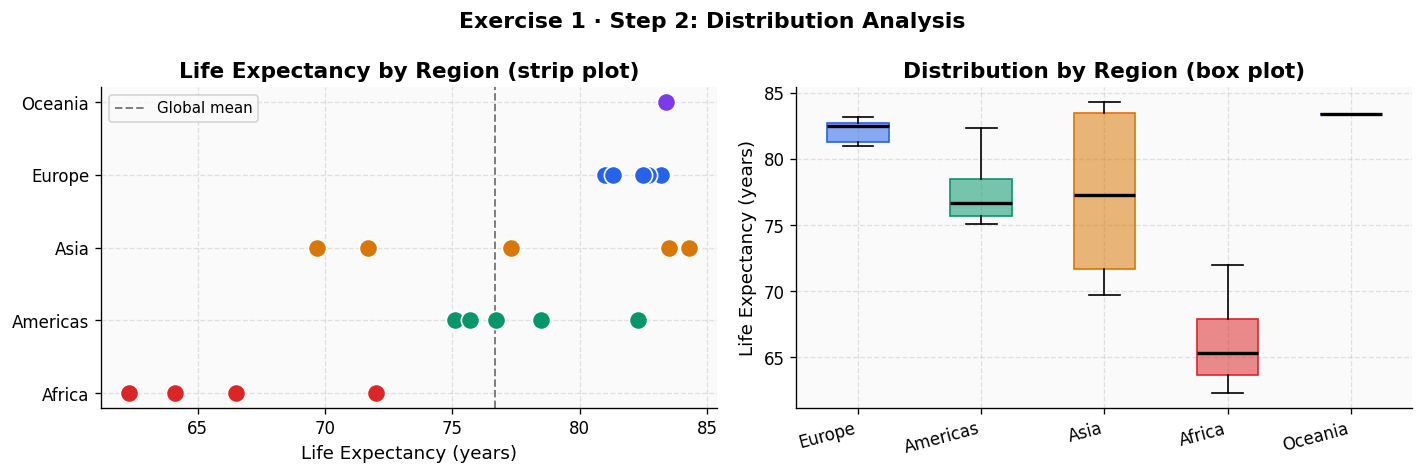


Observation: Europe/Oceania/Americas cluster high; Africa shows greatest spread.


In [ ]:
# Step 2: Distribution of life expectancy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram by region
for region, group in world_health.groupby('region'):
    axes[0].scatter(group['life_expectancy'],
                    [region] * len(group),
                    color=REGION_COLORS[region], s=120,
                    edgecolors='white', linewidths=1, zorder=3)
axes[0].set_xlabel('Life Expectancy (years)')
axes[0].set_title('Life Expectancy by Region (strip plot)')
axes[0].axvline(world_health['life_expectancy'].mean(), color='gray',
                linestyle='--', linewidth=1.2, label='Global mean')
axes[0].legend(fontsize=9)

# Box plot by region
data_by_region = [world_health[world_health['region']==r]['life_expectancy'].values
                  for r in REGION_COLORS]
bp = axes[1].boxplot(data_by_region, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], REGION_COLORS.values()):
    patch.set_facecolor(color + '88')
    patch.set_edgecolor(color)
axes[1].set_xticklabels(list(REGION_COLORS.keys()), rotation=15, ha='right')
axes[1].set_ylabel('Life Expectancy (years)')
axes[1].set_title('Distribution by Region (box plot)')

fig.suptitle('Exercise 1 · Step 2: Distribution Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nObservation: Europe/Oceania/Americas cluster high; Africa shows greatest spread.")


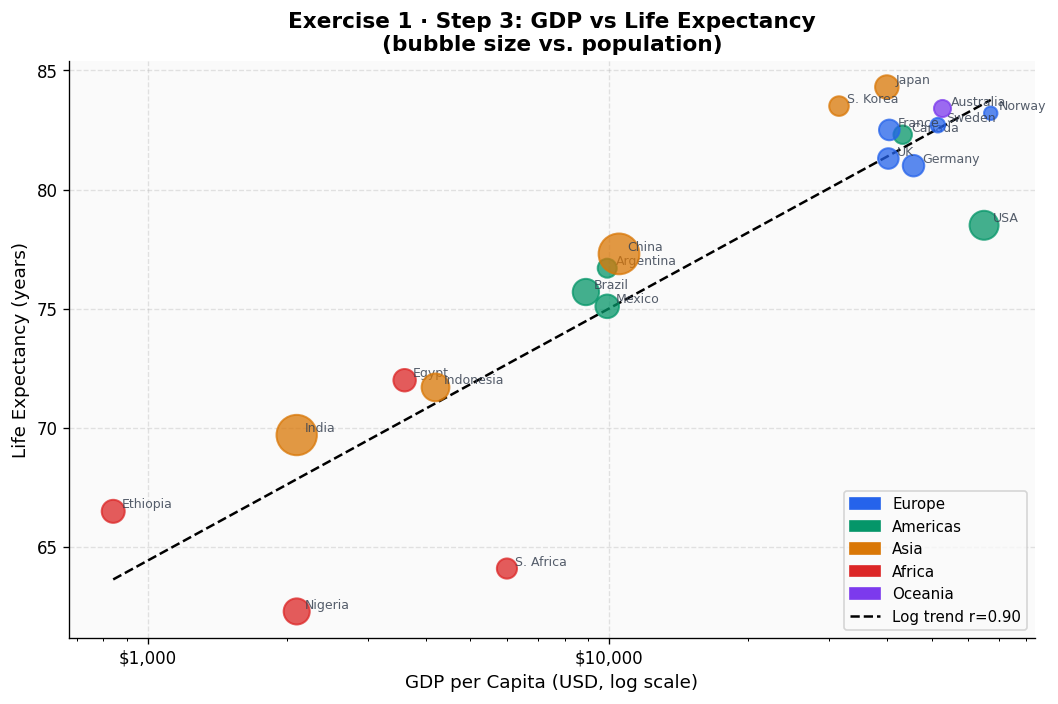


Pearson r (log GDP vs LE) = 0.897, p = 0.00000
Interpretation: Strong positive relationship on log scale. Returns to LE diminish at high GDP.


In [ ]:
# Step 3: Relationship between GDP and Life Expectancy
fig, ax = plt.subplots(figsize=(9, 6))

for region, group in world_health.groupby('region'):
    sizes = np.sqrt(group['population_M']) * 15 + 30
    ax.scatter(group['gdp_per_capita'], group['life_expectancy'],
               s=sizes, color=REGION_COLORS[region], alpha=0.75,
               edgecolors=REGION_COLORS[region], linewidths=1.2, label=region, zorder=3)
    for _, row in group.iterrows():
        ax.annotate(row['country'],
                    (row['gdp_per_capita'], row['life_expectancy']),
                    xytext=(5, 2), textcoords='offset points',
                    fontsize=7.5, color='#374151', alpha=0.85)

# Log-scale x and trend line
ax.set_xscale('log')
log_gdp = np.log(world_health['gdp_per_capita'])
life    = world_health['life_expectancy']
slope, intercept, r, p, se = stats.linregress(log_gdp, life)
x_fit = np.logspace(np.log10(world_health['gdp_per_capita'].min()),
                    np.log10(world_health['gdp_per_capita'].max()), 100)
ax.plot(x_fit, slope * np.log(x_fit) + intercept, 'k--',
        linewidth=1.5, label=f'Log trend  r={r:.2f}')

ax.set_xlabel('GDP per Capita (USD, log scale)')
ax.set_ylabel('Life Expectancy (years)')
ax.set_title('Exercise 1 · Step 3: GDP vs Life Expectancy\n(bubble size vs. population)',
             fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLORS.items()]
legend_patches.append(plt.Line2D([0],[0], linestyle='--', color='black', label=f'Log trend r={r:.2f}'))
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

print(f"\nPearson r (log GDP vs LE) = {r:.3f}, p = {p:.5f}")
print("Interpretation: Strong positive relationship on log scale. Returns to LE diminish at high GDP.")


# Exercise 1: Guided Questions

1. Why is the mean GDP **much higher** than the median? Which would you headline?
2. Which country has a **higher life expectancy than its GDP predicts**? What might explain this?
3. Which region has the **greatest within-region variation** in life expectancy?
4. Write a **one-sentence insight** from this dataset that could accompany a chart in a report.
5. Which **single chart type** would you show to a World Bank executive? Why?


## Exercise 2: Retail Sales Performance

**Dataset:** `monthly_sales`: 12 months × 4 categories (electronics, clothing, furniture, food)

Conduct a full performance analysis and build a stakeholder-ready narrative.


In [ ]:
# Full analysis: descriptive stats per category
cats = ['electronics', 'clothing', 'furniture', 'food']

print("=" * 65)
print("  RETAIL SALES — Descriptive Statistics by Category")
print("=" * 65)
print(f"  {'Category':<14} {'Mean':>7} {'Std':>7} {'CV%':>6} {'Min':>6} {'Max':>6} {'Q4 Avg':>8}")
print("  " + "-"*62)
for cat in cats:
    s = monthly_sales[cat]
    q4 = monthly_sales[cat].iloc[9:].mean()
    cv = s.std()/s.mean()*100
    print(f"  {cat.title():<14} {s.mean():>7.1f} {s.std():>7.1f} {cv:>5.1f}% {s.min():>6} {s.max():>6} {q4:>8.1f}")
print("=" * 65)
print("\nCV = Coefficient of Variation (lower = more stable throughout year)")


  RETAIL SALES — Descriptive Statistics by Category
  Category          Mean     Std    CV%    Min    Max   Q4 Avg
  --------------------------------------------------------------
  Electronics       58.1    17.6  30.2%     38     95     82.7
  Clothing          53.5    15.7  29.4%     32     85     75.0
  Furniture         49.4    10.7  21.6%     28     62     55.7
  Food              95.8    11.2  11.7%     82    125    109.0

CV = Coefficient of Variation (lower = more stable throughout year)


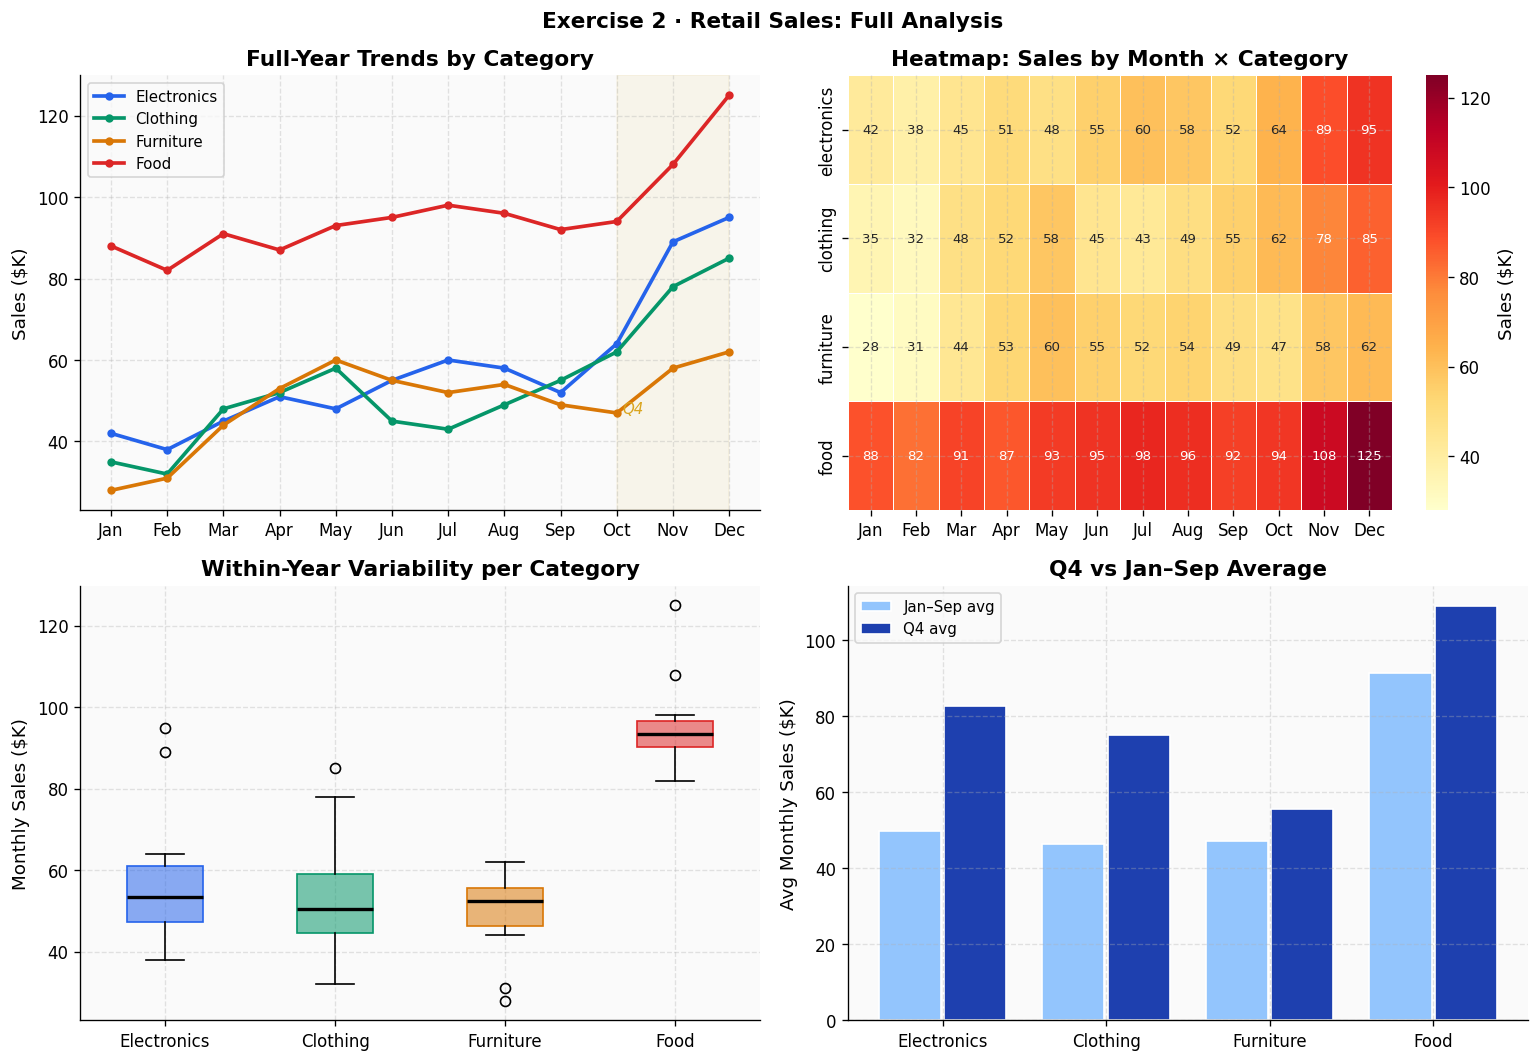

In [ ]:
# Full visualization suite
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

colors_dict = {'electronics': PALETTE['blue'], 'clothing': PALETTE['green'],
               'furniture': PALETTE['amber'], 'food': PALETTE['red']}

# 1) Multi-line trend
for cat, color in colors_dict.items():
    axes[0,0].plot(months, monthly_sales[cat], marker='o', markersize=4,
                   linewidth=2.2, color=color, label=cat.title())
axes[0,0].set_title('Full-Year Trends by Category')
axes[0,0].set_ylabel('Sales ($K)')
axes[0,0].legend(fontsize=9)
axes[0,0].axvspan(9, 11, alpha=0.07, color='goldenrod')
axes[0,0].text(9.1, 47, 'Q4', fontsize=9, color='goldenrod', fontstyle='italic')

# 2) Heatmap: month × category
heat_df = monthly_sales.set_index('month')[cats]
sns.heatmap(heat_df.T, ax=axes[0,1], cmap='YlOrRd', annot=True, fmt='.0f',
            annot_kws={'size':8}, linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Sales ($K)'})
axes[0,1].set_title('Heatmap: Sales by Month × Category')
axes[0,1].set_xlabel('')

# 3) Box plot: within-year variability
bp = axes[1,0].boxplot([monthly_sales[c] for c in cats], patch_artist=True,
                        labels=[c.title() for c in cats],
                        medianprops=dict(color='black', linewidth=2))
for patch, cat in zip(bp['boxes'], cats):
    patch.set_facecolor(colors_dict[cat] + '88')
    patch.set_edgecolor(colors_dict[cat])
axes[1,0].set_ylabel('Monthly Sales ($K)')
axes[1,0].set_title('Within-Year Variability per Category')

# 4) Q4 vs rest of year bar chart
q4_avg   = {cat: monthly_sales[cat].iloc[9:].mean()   for cat in cats}
rest_avg = {cat: monthly_sales[cat].iloc[:9].mean()   for cat in cats}
x_pos = np.arange(len(cats))
axes[1,1].bar(x_pos - 0.2, [rest_avg[c] for c in cats], 0.38,
              label='Jan–Sep avg', color='#93C5FD', edgecolor='white')
axes[1,1].bar(x_pos + 0.2, [q4_avg[c]   for c in cats], 0.38,
              label='Q4 avg',       color='#1E40AF', edgecolor='white')
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels([c.title() for c in cats])
axes[1,1].set_ylabel('Avg Monthly Sales ($K)')
axes[1,1].set_title('Q4 vs Jan–Sep Average')
axes[1,1].legend(fontsize=9)

fig.suptitle('Exercise 2 · Retail Sales: Full Analysis', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


## Capstone Challenge 3-Chart Stakeholder Presentation

Build a three-chart narrative following the data story arc.
The template below provides the structure — your job is to write the annotations and titles.

**Scoring rubric (1–5 each):**
| Criterion | 1 (poor) | 5 (excellent) |
|-----------|----------|---------------|
| **Accuracy** | Mislabeled axes | Fully labeled, sourced |
| **Chart type** | Wrong type for question | Ideal match |
| **Clarity** | Confusing in 30s | Insight clear in 10s |
| **Insight** | No takeaway | Clear, actionable finding |
| **Design** | Cluttered/decorative | Purposeful color, clean |


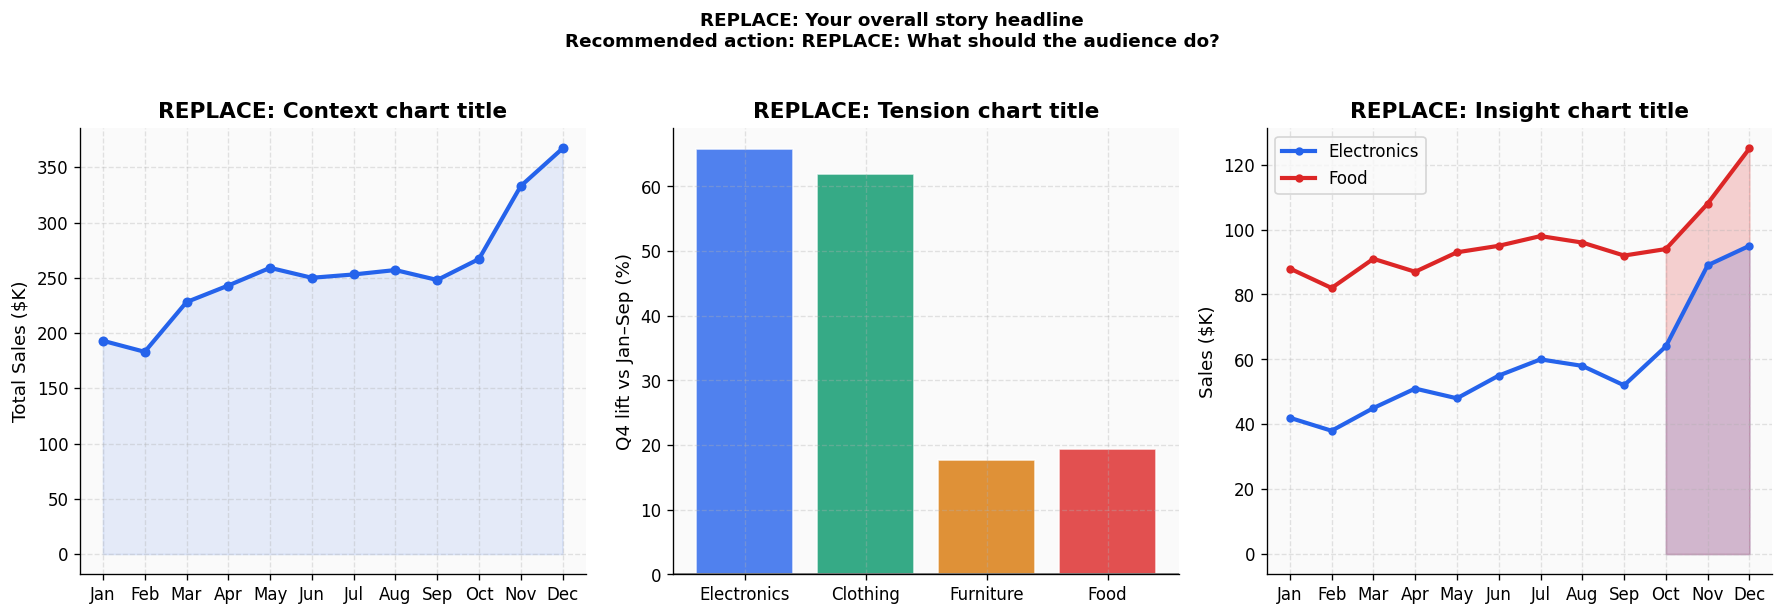


 Peer review: Share this chart with a classmate and score it using the rubric above.


In [ ]:
# CAPSTONE TEMPLATE: Complete the titles, annotations, and insights
# TODO: Fill in your narrative titles and annotations

STORY_TITLE     = "REPLACE: Your overall story headline"
CHART1_TITLE    = "REPLACE: Context chart title"
CHART1_SUBTITLE = "REPLACE: What does the baseline show?"
CHART2_TITLE    = "REPLACE: Tension chart title"
CHART2_ANNOTATION = "REPLACE: What's the problem or opportunity?"
CHART3_TITLE    = "REPLACE: Insight chart title"
RECOMMENDED_ACTION = "REPLACE: What should the audience do?"

#
# USE EITHER DATASET: world_health  OR  monthly_sales
# Below is a starter using monthly_sales. Modify freely
#

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Context
total_monthly = monthly_sales[['electronics','clothing','furniture','food']].sum(axis=1)
axes[0].plot(months, total_monthly, color=PALETTE['blue'], linewidth=2.5, marker='o', markersize=5)
axes[0].fill_between(range(len(months)), total_monthly, alpha=0.1, color=PALETTE['blue'])
axes[0].set_title(CHART1_TITLE, fontweight='bold')
axes[0].set_ylabel('Total Sales ($K)')
# TODO: Add a mean reference line and label it

# Chart 2: Tension
q4_lift = {cat: (monthly_sales[cat].iloc[9:].mean() /
                  monthly_sales[cat].iloc[:9].mean() - 1) * 100
           for cat in ['electronics','clothing','furniture','food']}
bars = axes[1].bar(list(q4_lift.keys()), list(q4_lift.values()),
                   color=[PALETTE['blue'], PALETTE['green'], PALETTE['amber'], PALETTE['red']],
                   alpha=0.8, edgecolor='white')
axes[1].axhline(0, color='gray', linewidth=1)
axes[1].set_title(CHART2_TITLE, fontweight='bold')
axes[1].set_ylabel('Q4 lift vs Jan–Sep (%)')
axes[1].set_xticklabels([c.title() for c in list(q4_lift.keys())])
# TODO: Annotate the bar showing the most surprising finding

# Chart 3: Insight
for cat, color in [('electronics', PALETTE['blue']), ('food', PALETTE['red'])]:
    axes[2].plot(months, monthly_sales[cat], color=color, linewidth=2.5,
                 marker='o', markersize=4, label=cat.title())
    # Highlight Q4
    axes[2].fill_between(range(9, 12),
                         monthly_sales[cat].values[9:],
                         alpha=0.2, color=color)
axes[2].set_title(CHART3_TITLE, fontweight='bold')
axes[2].set_ylabel('Sales ($K)')
axes[2].legend(fontsize=10)
# TODO: Add a text annotation with your key insight

fig.suptitle(STORY_TITLE + f'\nRecommended action: {RECOMMENDED_ACTION}',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n Peer review: Share this chart with a classmate and score it using the rubric above.")


---
## Module Summary: The 5 Rules

| # | Rule |
|---|------|
| 1 | Always explore data with **descriptive statistics** before choosing a chart type |
| 2 | Match your chart type to your **data question** — not to what looks impressive |
| 3 | Use color to encode **meaning**, not to decorate. Gray + one accent often beats a rainbow |
| 4 | **Annotate** your key insight explicitly — never make the reader find it |
| 5 | Know your **audience**: their context, their decision, the one action you want them to take |
